# SC3021 Deliverable 2 - Road Safety Data Preparation and Early Analysis

## Research Question
How can accident-casualty trends in Singapore be prepared and enriched using accident, rainfall, and vehicle-population datasets to support descriptive and diagnostic road-safety analysis?

This notebook is structured in the style of the SC3021 Deliverable 2 exemplars. It documents source selection, profiling, structuring, cleaning, enriching, and the construction of a final analysis-ready dataset.

This version is configured for Google Colab. Upload the five CSV files when prompted, then run the notebook top to bottom.


## Table of Contents

1. Problem Definition (Ask)
2. Data Requirements Analysis (Prepare)
3. Source Selection and Suitability (Prepare)
4. Setup and Helper Functions
5. Load Raw Datasets
6. Raw Data Profiling
7. Data Preparation Strategy (Prepare + Process)
8. DS1 Preparation - Accident Causes by Severity
9. DS2 Preparation - Monthly Casualties
10. DS3 Preparation - Annual Vehicle Involvement Context
11. DS4 Preparation - Monthly Rainfall
12. DS5 Preparation - Monthly Vehicle Population
13. Data Enrichment and Integration (Process)
14. Final Dataset Profiling
15. Descriptive Analytics
16. Seasonality, Composition, and Anomaly Analysis
17. Dependency and Association Analysis
18. Predictive Analytics (Regression-First, Classification Exploratory)
19. Deliverable 2 Talking Points


## 1. Problem Definition (Ask)

Road-traffic safety is affected by multiple factors including accident causes, weather conditions, and road-use exposure. To prepare for downstream analysis, the data must be profiled, cleaned, aligned to a common temporal granularity, and integrated into an analysis-ready table.

This Deliverable 2 focuses on the data engineering and preparation steps needed to support later descriptive, diagnostic, and predictive analysis.


## 2. Data Requirements Analysis (Prepare)

To study road-safety outcomes at a monthly level, the following data requirements are relevant:

- A monthly casualty target series to quantify road-safety outcomes.
- Explanatory variables at the same monthly granularity, such as weather and vehicle population.
- Contextual accident-cause information to explain severity patterns.
- Supporting annual context for vehicle involvement in fatal and injury accidents.

These requirements suggest a target table centered on monthly casualties, enriched with rainfall and vehicle-population features, while accident-cause and annual vehicle-involvement data remain useful as supporting context.


## 3. Source Selection and Suitability (Prepare)

### Selected Datasets

- **DS1**: `CausesofAccidentsbySeverityofInjurySustained.csv`
  - Relevant for understanding which causes are most associated with fatal and injury accidents.
  - Useful for descriptive and diagnostic context.

- **DS2**: `RoadTrafficAccidentCasualtiesMonthly.csv`
  - Main target dataset containing monthly casualties across road-user categories.
  - Best suited as the central dataset for the final analytical table.

- **DS3**: `VehiclesInvolvedInFatalAndInjuryRoadTrafficAccidentsByTypeOfVehicleAnnual.csv`
  - Useful as annual context on vehicle involvement.
  - Not ideal for direct monthly integration because its granularity is yearly.

- **DS4**: `RainfallMonthlyTotal.csv`
  - Monthly weather enrichment source.
  - Aligns well with DS2 by month.

- **DS5**: `MonthlyMotorVehiclePopulationbyVehicleType.csv`
  - Monthly exposure-related enrichment source.
  - Useful for linking road-use intensity with casualties.

### Suitability Summary

The five datasets collectively support a meaningful Deliverable 2 pipeline because they offer complementary views of the road-safety problem. DS2 is the strongest candidate for the final target series, while DS4 and DS5 provide natural enrichment at the monthly level. DS1 and DS3 are better used as contextual sources to explain severity and vehicle-type patterns.


In [1]:
import warnings
from pathlib import Path
import re
import textwrap

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

PRIMARY = "#0f766e"
SECONDARY = "#2563eb"
ACCENT = "#f97316"
NEGATIVE = "#dc2626"
NEUTRAL = "#64748b"

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)

REQUIRED_FILES = [
    "CausesofAccidentsbySeverityofInjurySustained.csv",
    "RoadTrafficAccidentCasualtiesMonthly.csv",
    "VehiclesInvolvedInFatalAndInjuryRoadTrafficAccidentsByTypeOfVehicleAnnual.csv",
    "RainfallMonthlyTotal.csv",
    "MonthlyMotorVehiclePopulationbyVehicleType.csv",
]

OUTPUT_DIR = Path("road_safety_deliverable2_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

try:
    from google.colab import files  # type: ignore
    IN_COLAB = True
except Exception:
    files = None
    IN_COLAB = False


def ensure_uploaded_files(required_files):
    missing = [name for name in required_files if not Path(name).exists()]
    if missing and IN_COLAB:
        print("Please upload these CSV files:")
        for name in missing:
            print("-", name)
        uploaded = files.upload()
        print("Uploaded files:", list(uploaded.keys()))
        missing = [name for name in required_files if not Path(name).exists()]

    if missing:
        raise FileNotFoundError(
            "Missing required CSV files: " + ", ".join(missing) +
            ". In Colab, run the cell again and upload them when prompted."
        )


def load_csv(filename):
    return pd.read_csv(Path(filename))


ensure_uploaded_files(REQUIRED_FILES)
print("Colab mode:", IN_COLAB)
print("Output directory:", OUTPUT_DIR)


Colab mode: True
Output directory: road_safety_deliverable2_outputs


In [2]:
def heading(title):
    print()
    print("=" * 100)
    print(title)
    print("=" * 100)


def normalize_colnames(df):
    df = df.copy()
    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.lower()
        .str.replace(r"[^a-z0-9]+", "_", regex=True)
        .str.strip("_")
    )
    return df


def safe_display(obj, n=5):
    try:
        display(obj.head(n) if isinstance(obj, pd.DataFrame) else obj)
    except Exception:
        print(obj.head(n) if isinstance(obj, pd.DataFrame) else obj)


def save_csv(df, filename):
    path = OUTPUT_DIR / filename
    df.to_csv(path, index=False)
    print(f"Saved: {path}")


def slugify(text):
    return re.sub(r"[^a-z0-9]+", "_", str(text).strip().lower()).strip("_")


def vehicle_type_standardize(text):
    value = str(text).strip()
    mapping = {
        "Rental cars": "Rental Cars",
    }
    return mapping.get(value, value)


def parse_month_label(value):
    value = str(value).strip()
    return pd.to_datetime(value, format="%Y%b", errors="coerce")


def clean_label(text, width=24):
    text = str(text).replace("_", " ").strip()
    wrapped = textwrap.wrap(text, width=width)
    return "\n".join(wrapped) if wrapped else text


def profile_dataset(df, name):
    heading(f"{name} - PROFILE")
    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())
    profile = pd.DataFrame({
        "column": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "missing_count": df.isna().sum().values,
        "missing_pct": (df.isna().mean().values * 100).round(2),
        "distinct_values": [df[c].nunique(dropna=True) for c in df.columns],
    }).sort_values(["missing_pct", "missing_count"], ascending=False)
    safe_display(df, n=5)
    safe_display(profile, n=len(profile))
    try:
        safe_display(df.describe(include="all").T, n=len(df.columns))
    except Exception:
        print(df.describe(include="all").T)
    return profile


def bar_plot(x, y, title, xlabel, ylabel, rotation=0, figsize=(10, 5), horizontal=False, color=None):
    labels = [str(v) for v in x]
    values = pd.Series(y).astype(float).tolist()
    auto_horizontal = horizontal or max(len(lbl) for lbl in labels) > 20 or rotation >= 45
    plot_color = color or PRIMARY

    fig, ax = plt.subplots(figsize=figsize)
    if auto_horizontal:
        wrapped = [clean_label(lbl, width=30) for lbl in labels]
        bars = ax.barh(wrapped, values, color=plot_color, edgecolor="white", alpha=0.92)
        ax.invert_yaxis()
        x_offset = (max(values) * 0.01) if values else 0.1
        for bar, value in zip(bars, values):
            ax.text(value + x_offset, bar.get_y() + bar.get_height() / 2, f"{value:,.0f}", va="center", ha="left", fontsize=9, color="#0f172a")
        ax.grid(axis="x", linestyle="--", alpha=0.25)
        ax.grid(axis="y", visible=False)
    else:
        wrapped = [clean_label(lbl, width=16) for lbl in labels]
        bars = ax.bar(wrapped, values, color=plot_color, edgecolor="white", alpha=0.92)
        y_offset = (max(values) * 0.015) if values else 0.1
        for bar, value in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width() / 2, value + y_offset, f"{value:,.0f}", va="bottom", ha="center", fontsize=9, color="#0f172a")
        ax.tick_params(axis="x", rotation=rotation)
        ax.grid(axis="y", linestyle="--", alpha=0.25)
        ax.grid(axis="x", visible=False)

    ax.set_title(title, pad=14, weight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()


def line_plot(x, y, title, xlabel, ylabel, marker=None, figsize=(10, 5), color=None):
    fig, ax = plt.subplots(figsize=figsize)
    line_color = color or SECONDARY
    ax.plot(x, y, marker=marker, linewidth=2.4, color=line_color, markerfacecolor=ACCENT, markeredgecolor="white", markersize=6)
    ax.set_title(title, pad=14, weight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.25, linestyle="--")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if len(x) > 12:
        first_item = x.iloc[0] if hasattr(x, 'iloc') else x[0]
        if hasattr(first_item, 'year'):
            ax.xaxis.set_major_locator(mdates.YearLocator())
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.tight_layout()
    plt.show()


def scatter_plot(x, y, title, xlabel, ylabel, figsize=(8, 5), color=None):
    fig, ax = plt.subplots(figsize=figsize)
    plot_color = color or ACCENT
    ax.scatter(x, y, s=55, alpha=0.78, color=plot_color, edgecolor="white", linewidth=0.7)
    try:
        x_num = pd.Series(x).astype(float)
        y_num = pd.Series(y).astype(float)
        valid = x_num.notna() & y_num.notna()
        if valid.sum() >= 2:
            coef = np.polyfit(x_num[valid], y_num[valid], 1)
            trend_x = np.linspace(x_num[valid].min(), x_num[valid].max(), 100)
            trend_y = coef[0] * trend_x + coef[1]
            ax.plot(trend_x, trend_y, color=PRIMARY, linewidth=2.0, linestyle='--')
    except Exception:
        pass
    ax.set_title(title, pad=14, weight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.25, linestyle="--")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()


## 4. Load Raw Datasets

The first preparation step is to load the raw files and standardize the column names so the rest of the pipeline can be written consistently.


In [3]:
heading("LOAD RAW DATASETS")

df1 = normalize_colnames(load_csv("CausesofAccidentsbySeverityofInjurySustained.csv"))
df2 = load_csv("RoadTrafficAccidentCasualtiesMonthly.csv")
df3 = load_csv("VehiclesInvolvedInFatalAndInjuryRoadTrafficAccidentsByTypeOfVehicleAnnual.csv")
df4 = normalize_colnames(load_csv("RainfallMonthlyTotal.csv"))
df5 = normalize_colnames(load_csv("MonthlyMotorVehiclePopulationbyVehicleType.csv"))

for name, df in [("DS1", df1), ("DS2", df2), ("DS3", df3), ("DS4", df4), ("DS5", df5)]:
    print(f"{name} shape = {df.shape}")



LOAD RAW DATASETS
DS1 shape = (328, 5)
DS2 shape = (30, 204)
DS3 shape = (8, 10)
DS4 shape = (528, 2)
DS5 shape = (444, 3)


## 5. Raw Data Profiling

Following the course materials, profiling is performed before transformation. We examine basic structure, data types, missingness, and distinct-value patterns for each dataset.


In [4]:
profile_ds1 = profile_dataset(df1, "DS1 Raw")
profile_ds2 = profile_dataset(df2, "DS2 Raw")
profile_ds3 = profile_dataset(df3, "DS3 Raw")
profile_ds4 = profile_dataset(df4, "DS4 Raw")
profile_ds5 = profile_dataset(df5, "DS5 Raw")



DS1 Raw - PROFILE
Shape: (328, 5)
Columns: ['year', 'accident_classification', 'road_user_group', 'causes_of_accident', 'number_of_accidents']


,year,accident_classification,road_user_group,causes_of_accident,number_of_accidents
0,2012,FATAL,"Drivers, Riders or Cyclists",Failing to Keep a Proper Lookout,59
1,2012,FATAL,"Drivers, Riders or Cyclists",Failing to Have Proper Control,50
2,2012,FATAL,"Drivers, Riders or Cyclists",Failing to Give Way to Traffic with Right of Way,9
3,2012,FATAL,"Drivers, Riders or Cyclists",Changing Lane without Due Care,6
4,2012,FATAL,"Drivers, Riders or Cyclists",Disobeying Traffic Light Signals Resulting in ...,9


,column,dtype,missing_count,missing_pct,distinct_values
2,road_user_group,object,42,12.8,2
0,year,int64,0,0.0,7
1,accident_classification,object,0,0.0,2
3,causes_of_accident,object,0,0.0,24
4,number_of_accidents,int64,0,0.0,120


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
year,328.0,NaN,NaN,NaN,2015.036585,2.005772,2012.0,2013.0,2015.0,2017.0,2018.0
accident_classification,328,2,FATAL,164,NaN,NaN,NaN,NaN,NaN,NaN,NaN
road_user_group,286,2,"Drivers, Riders or Cyclists",154,NaN,NaN,NaN,NaN,NaN,NaN,NaN
causes_of_accident,328,24,Failing to Keep a Proper Lookout,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
number_of_accidents,328.0,NaN,NaN,NaN,140.121951,403.8008,0.0,2.0,8.0,56.5,2742.0



DS2 Raw - PROFILE
Shape: (30, 204)
Columns: ['DataSeries', '2025Nov', '2025Oct', '2025Sep', '2025Aug', '2025Jul', '2025Jun', '2025May', '2025Apr', '2025Mar', '2025Feb', '2025Jan', '2024Dec', '2024Nov', '2024Oct', '2024Sep', '2024Aug', '2024Jul', '2024Jun', '2024May', '2024Apr', '2024Mar', '2024Feb', '2024Jan', '2023Dec', '2023Nov', '2023Oct', '2023Sep', '2023Aug', '2023Jul', '2023Jun', '2023May', '2023Apr', '2023Mar', '2023Feb', '2023Jan', '2022Dec', '2022Nov', '2022Oct', '2022Sep', '2022Aug', '2022Jul', '2022Jun', '2022May', '2022Apr', '2022Mar', '2022Feb', '2022Jan', '2021Dec', '2021Nov', '2021Oct', '2021Sep', '2021Aug', '2021Jul', '2021Jun', '2021May', '2021Apr', '2021Mar', '2021Feb', '2021Jan', '2020Dec', '2020Nov', '2020Oct', '2020Sep', '2020Aug', '2020Jul', '2020Jun', '2020May', '2020Apr', '2020Mar', '2020Feb', '2020Jan', '2019Dec', '2019Nov', '2019Oct', '2019Sep', '2019Aug', '2019Jul', '2019Jun', '2019May', '2019Apr', '2019Mar', '2019Feb', '2019Jan', '2018Dec', '2018Nov', '2018

...

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
month,528,528,2024-08,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_rainfall,528.0,NaN,NaN,NaN,180.041288,114.742194,0.2,96.75,160.8,239.65,765.9



DS5 Raw - PROFILE
Shape: (444, 3)
Columns: ['month', 'vehicle_type', 'number']


,month,vehicle_type,number
0,2012-01,Cars,593555
1,2012-01,Rental Cars,13970
2,2012-01,Taxi,27059
3,2012-01,Buses,17037
4,2012-01,Goods & Other Vehicles,159854


,column,dtype,missing_count,missing_pct,distinct_values
0,month,object,0,0.0,74
1,vehicle_type,object,0,0.0,9
2,number,int64,0,0.0,440


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
month,444,74,2012-01,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vehicle_type,444,9,Taxi,74,NaN,NaN,NaN,NaN,NaN,NaN,NaN
number,444.0,NaN,NaN,NaN,160577.155405,198119.328833,13970.0,19371.25,104473.5,160561.25,607292.0


## 6. Data Preparation Strategy (Prepare + Process)

The notebook is organized to make the **Prepare** and **Process** stages explicit.

**Prepare stage**
- profile each source to understand structure, granularity, missingness, and suitability,
- justify why each dataset is included as a target, enrichment, or contextual source,
- clean inconsistent labels, invalid records, and data types before integration.

**Process stage**
- restructure wide monthly tables into tidy monthly rows,
- standardize all core sources to a common monthly time key,
- enrich the target series with rainfall and vehicle-exposure information,
- derive a small set of analysis-ready calendar and lag features after integration.

This structure keeps the notebook aligned with Deliverable 2, where the main emphasis is on source selection, data preparation, and data processing quality rather than on advanced modeling alone.


## 7. DS1 Preparation - Accident Causes by Severity

DS1 already has a tabular structure, so the main work is cleaning and contextual summarization rather than reshaping. The dataset is useful for understanding accident-cause composition across fatal and injury outcomes.



DS1 PREPARATION

DS1 Clean - PROFILE
Shape: (328, 5)
Columns: ['year', 'accident_classification', 'road_user_group', 'causes_of_accident', 'number_of_accidents']


,year,accident_classification,road_user_group,causes_of_accident,number_of_accidents
0,2012,FATAL,"Drivers, Riders or Cyclists",Failing to Keep a Proper Lookout,59
1,2012,FATAL,"Drivers, Riders or Cyclists",Failing to Have Proper Control,50
2,2012,FATAL,"Drivers, Riders or Cyclists",Failing to Give Way to Traffic with Right of Way,9
3,2012,FATAL,"Drivers, Riders or Cyclists",Changing Lane without Due Care,6
4,2012,FATAL,"Drivers, Riders or Cyclists",Disobeying Traffic Light Signals Resulting in ...,9


,column,dtype,missing_count,missing_pct,distinct_values
0,year,int64,0,0.0,7
1,accident_classification,object,0,0.0,2
2,road_user_group,object,0,0.0,3
3,causes_of_accident,object,0,0.0,24
4,number_of_accidents,int64,0,0.0,120


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
year,328.0,NaN,NaN,NaN,2015.036585,2.005772,2012.0,2013.0,2015.0,2017.0,2018.0
accident_classification,328,2,FATAL,164,NaN,NaN,NaN,NaN,NaN,NaN,NaN
road_user_group,328,3,"Drivers, Riders or Cyclists",154,NaN,NaN,NaN,NaN,NaN,NaN,NaN
causes_of_accident,328,24,Failing to Keep a Proper Lookout,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
number_of_accidents,328.0,NaN,NaN,NaN,140.121951,403.8008,0.0,2.0,8.0,56.5,2742.0


,accident_classification,number_of_accidents
1,INJURY,44831
0,FATAL,1129


,causes_of_accident,number_of_accidents
11,Failing to Keep a Proper Lookout,17278
10,Failing to Have Proper Control,7679
9,Failing to Give Way to Traffic with Right of Way,5923
16,"Other causes attributed to drivers, riders or ...",3926
3,Changing Lane without Due Care,3449
20,Turning Without Due Care,1304
7,Disobeying Traffic Light Signals Resulting in ...,1192
4,Crossing Heedless of Traffic,945
15,Other Causes of Accidents Attributed to Pedest...,799
8,Driving under the Influence of Alcohol,613


,accident_classification,causes_of_accident,number_of_accidents,pct_within_severity
11,FATAL,Failing to Keep a Proper Lookout,337,29.85
10,FATAL,Failing to Have Proper Control,253,22.41
16,FATAL,"Other causes attributed to drivers, riders or ...",122,10.81
9,FATAL,Failing to Give Way to Traffic with Right of Way,57,5.05
14,FATAL,Other Causes,54,4.78
35,INJURY,Failing to Keep a Proper Lookout,16941,37.79
34,INJURY,Failing to Have Proper Control,7426,16.56
33,INJURY,Failing to Give Way to Traffic with Right of Way,5866,13.08
40,INJURY,"Other causes attributed to drivers, riders or ...",3804,8.49
27,INJURY,Changing Lane without Due Care,3416,7.62


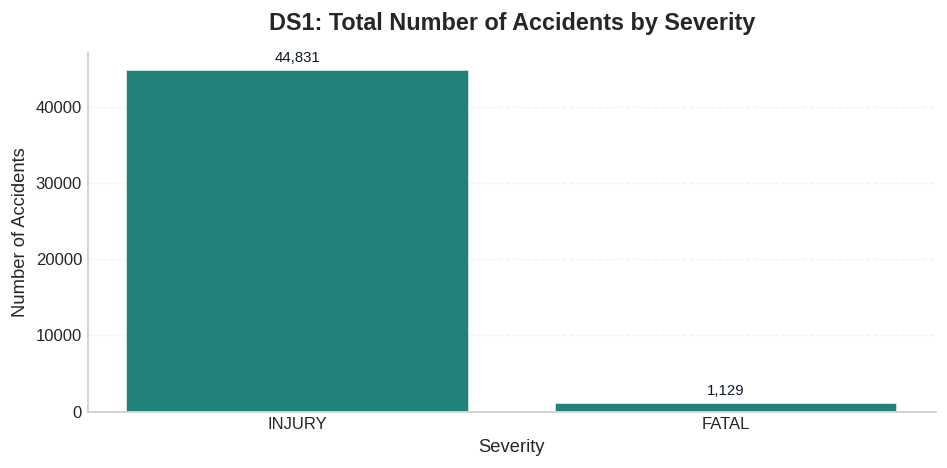

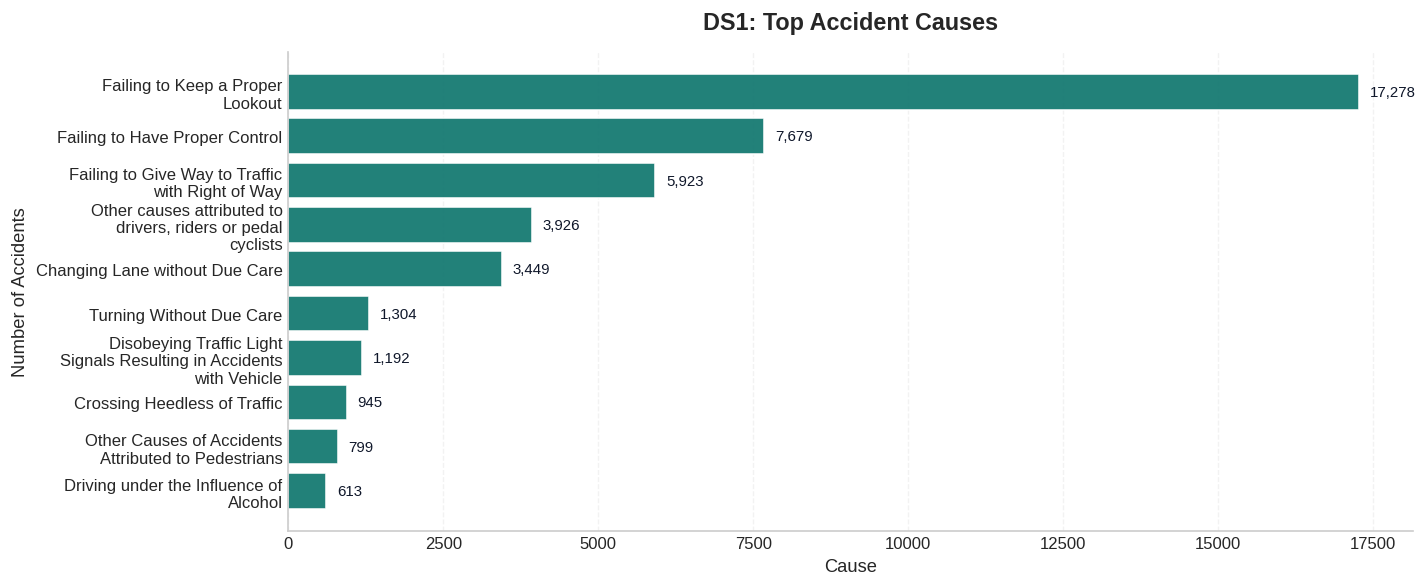

Saved: road_safety_deliverable2_outputs/ds1_clean.csv
Saved: road_safety_deliverable2_outputs/ds1_severity_totals.csv
Saved: road_safety_deliverable2_outputs/ds1_top_causes.csv


In [5]:
heading("DS1 PREPARATION")

df1_clean = df1.copy()
df1_clean["accident_classification"] = df1_clean["accident_classification"].astype(str).str.strip().str.upper()
df1_clean["causes_of_accident"] = df1_clean["causes_of_accident"].astype(str).str.strip()
df1_clean["road_user_group"] = df1_clean["road_user_group"].fillna("Unknown").astype(str).str.strip()
df1_clean["year"] = pd.to_numeric(df1_clean["year"], errors="coerce")
df1_clean["number_of_accidents"] = pd.to_numeric(df1_clean["number_of_accidents"], errors="coerce")
df1_clean = df1_clean.dropna(subset=["year", "number_of_accidents"]).drop_duplicates()

profile_dataset(df1_clean, "DS1 Clean")

severity_totals = (
    df1_clean.groupby("accident_classification", as_index=False)["number_of_accidents"]
    .sum()
    .sort_values("number_of_accidents", ascending=False)
)

top_causes = (
    df1_clean.groupby("causes_of_accident", as_index=False)["number_of_accidents"]
    .sum()
    .sort_values("number_of_accidents", ascending=False)
    .head(10)
)

severity_cause_pct = (
    df1_clean.groupby(["accident_classification", "causes_of_accident"], as_index=False)["number_of_accidents"]
    .sum()
)
severity_cause_pct["pct_within_severity"] = (
    severity_cause_pct.groupby("accident_classification")["number_of_accidents"]
    .transform(lambda s: (s / s.sum() * 100).round(2))
)

safe_display(severity_totals, n=len(severity_totals))
safe_display(top_causes, n=len(top_causes))
safe_display(severity_cause_pct.sort_values(["accident_classification", "number_of_accidents"], ascending=[True, False]).groupby("accident_classification").head(5), n=10)

bar_plot(
    severity_totals["accident_classification"],
    severity_totals["number_of_accidents"],
    "DS1: Total Number of Accidents by Severity",
    "Severity",
    "Number of Accidents",
    figsize=(8, 4),
)

bar_plot(
    top_causes["causes_of_accident"],
    top_causes["number_of_accidents"],
    "DS1: Top Accident Causes",
    "Cause",
    "Number of Accidents",
    rotation=75,
    figsize=(12, 5),
)

save_csv(df1_clean, "ds1_clean.csv")
save_csv(severity_totals, "ds1_severity_totals.csv")
save_csv(top_causes, "ds1_top_causes.csv")


## 8. DS2 Preparation - Monthly Casualties

DS2 is the central dataset for this project, but it is stored in a wide monthly format. Therefore, a major structuring step is required: the table is reshaped into long format and the monthly casualty target is derived from the two total series.



DS2 PREPARATION

DS2 Long - PROFILE
Shape: (5636, 7)
Columns: ['DataSeries', 'month_raw', 'value', 'month', 'year', 'month_num', 'dataseries']


,DataSeries,month_raw,value,month,year,month_num,dataseries
0,Total Casualties Fatalities,2025Nov,13.0,2025-11-01,2025,11,Total Casualties Fatalities
1,Pedestrians,2025Nov,4.0,2025-11-01,2025,11,Pedestrians
2,Personal Mobility Device Users,2025Nov,0.0,2025-11-01,2025,11,Personal Mobility Device Users
3,Cyclists & Pillions,2025Nov,4.0,2025-11-01,2025,11,Cyclists & Pillions
4,Motor Cyclists & Pillion Riders,2025Nov,5.0,2025-11-01,2025,11,Motor Cyclists & Pillion Riders


,column,dtype,missing_count,missing_pct,distinct_values
0,DataSeries,object,0,0.0,16
1,month_raw,object,0,0.0,203
2,value,float64,0,0.0,495
3,month,datetime64[ns],0,0.0,203
4,year,int32,0,0.0,17
5,month_num,int32,0,0.0,12
6,dataseries,object,0,0.0,16


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
DataSeries,5636,16,Pedestrians,406,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month_raw,5636,203,2022Jul,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
value,5636.0,NaN,NaN,NaN,60.969482,0.0,0.0,3.0,28.0,1055.0,166.355157
month,5636,NaN,NaN,NaN,2017-07-05 17:05:34.705465088,2009-01-01 00:00:00,2013-04-01 00:00:00,2017-08-01 00:00:00,2021-10-01 00:00:00,2025-11-01 00:00:00,NaN
year,5636.0,NaN,NaN,NaN,2017.055181,2009.0,2013.0,2017.0,2021.0,2025.0,4.878721
month_num,5636.0,NaN,NaN,NaN,6.474273,1.0,3.0,6.0,9.0,12.0,3.433053
dataseries,5636,16,Pedestrians,406,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,dataseries,value
14,Total Casualties Injured,163293.0
7,Motor Cyclists & Pillion Riders,79799.0
6,Motor Cars And Station Wagons,41541.0
9,Pedestrians,15965.0
1,Cyclists & Pillions,9887.0
5,"Lorries, Tipper Trucks & Trailers",8529.0
4,Lorries,7905.0
0,Buses,4994.0
3,Goods Vans & Pick-Ups,3668.0
2,Goods Vans,3457.0


,month,year,month_num,fatalities,injured,total_casualties,fatality_rate_pct
0,2009-01-01,2009,1,13.0,898.0,911.0,1.43
1,2009-02-01,2009,2,12.0,853.0,865.0,1.39
2,2009-03-01,2009,3,11.0,918.0,929.0,1.18
3,2009-04-01,2009,4,14.0,897.0,911.0,1.54
4,2009-05-01,2009,5,22.0,927.0,949.0,2.32


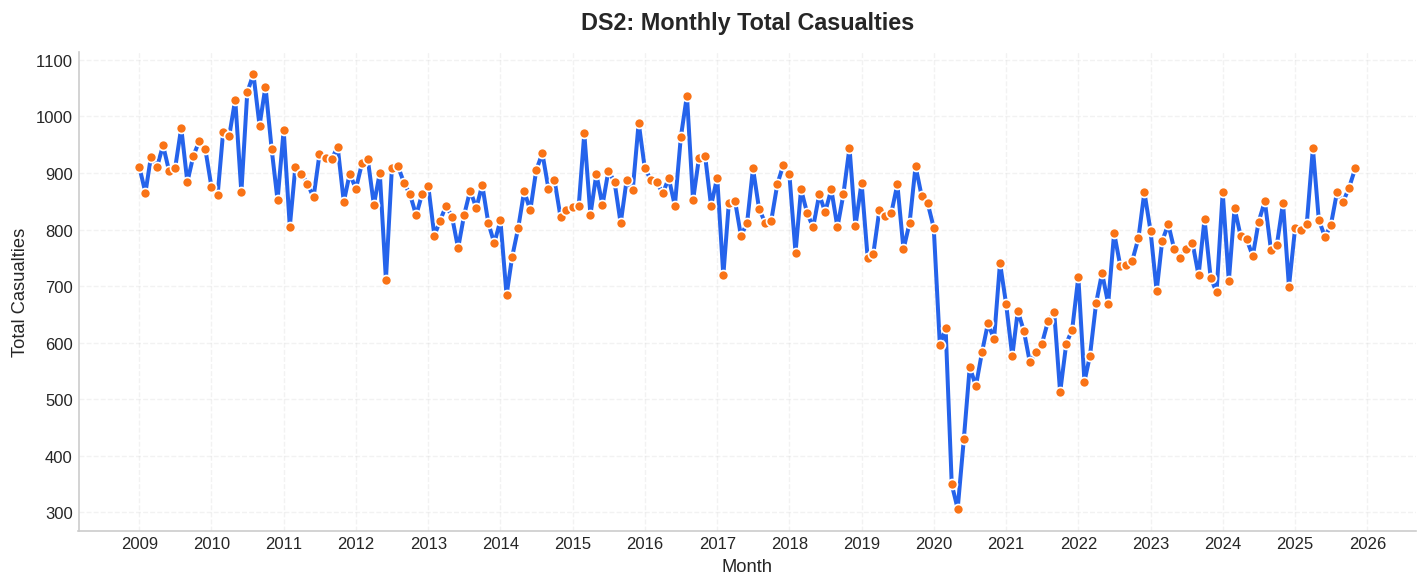

Saved: road_safety_deliverable2_outputs/ds2_long.csv
Saved: road_safety_deliverable2_outputs/target_monthly.csv
Saved: road_safety_deliverable2_outputs/ds2_series_totals.csv


In [6]:
heading("DS2 PREPARATION")

month_cols_2 = [c for c in df2.columns if c != "DataSeries"]

df2_long = df2.melt(
    id_vars="DataSeries",
    value_vars=month_cols_2,
    var_name="month_raw",
    value_name="value",
).copy()

df2_long["value"] = pd.to_numeric(df2_long["value"], errors="coerce")
df2_long["month"] = df2_long["month_raw"].apply(parse_month_label)
df2_long = df2_long.dropna(subset=["month", "value"]).drop_duplicates()
df2_long["year"] = df2_long["month"].dt.year
df2_long["month_num"] = df2_long["month"].dt.month
df2_long["dataseries"] = df2_long["DataSeries"].astype(str).str.strip()

profile_dataset(df2_long, "DS2 Long")

fatalities_monthly = (
    df2_long[df2_long["dataseries"] == "Total Casualties Fatalities"][["month", "year", "month_num", "value"]]
    .rename(columns={"value": "fatalities"})
    .sort_values("month")
)

injured_monthly = (
    df2_long[df2_long["dataseries"] == "Total Casualties Injured"][["month", "value"]]
    .rename(columns={"value": "injured"})
    .sort_values("month")
)

target_monthly = fatalities_monthly.merge(injured_monthly, on="month", how="inner")
target_monthly["total_casualties"] = target_monthly["fatalities"] + target_monthly["injured"]
target_monthly["fatality_rate_pct"] = (target_monthly["fatalities"] / target_monthly["total_casualties"] * 100).round(2)

series_totals = (
    df2_long.groupby("dataseries", as_index=False)["value"]
    .sum()
    .sort_values("value", ascending=False)
)

safe_display(series_totals.head(12), n=12)
safe_display(target_monthly.head(), n=5)

line_plot(
    target_monthly.sort_values("month")["month"],
    target_monthly.sort_values("month")["total_casualties"],
    "DS2: Monthly Total Casualties",
    "Month",
    "Total Casualties",
    marker="o",
    figsize=(12, 5),
)

save_csv(df2_long, "ds2_long.csv")
save_csv(target_monthly, "target_monthly.csv")
save_csv(series_totals, "ds2_series_totals.csv")


## 9. DS3 Preparation - Annual Vehicle Involvement Context

DS3 is annual rather than monthly, so it is treated as contextual data. It is still useful after a wide-to-long transformation because it supports yearly descriptive comparisons.



DS3 PREPARATION

DS3 Long - PROFILE
Shape: (72, 3)
Columns: ['DataSeries', 'year', 'value']


,DataSeries,year,value
0,Total,2023,13507
1,Bicycles And Power Assisted Bicycles,2023,598
2,Motor Cycles & Scooters,2023,4157
3,Motor Cars & Station Wagons,2023,6409
4,Goods Vans & Pick-Ups,2023,689


,column,dtype,missing_count,missing_pct,distinct_values
0,DataSeries,object,0,0.0,8
1,year,int64,0,0.0,9
2,value,int64,0,0.0,71


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
DataSeries,72,8,Total,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,72.0,NaN,NaN,NaN,2019.0,2.600108,2015.0,2017.0,2019.0,2021.0,2023.0
value,72.0,NaN,NaN,NaN,3316.194444,4364.712777,57.0,512.25,778.5,4776.0,15369.0


,DataSeries,year,value
64,Total,2015,14982
56,Total,2016,15369
48,Total,2017,14168
40,Total,2018,14062
32,Total,2019,14133
24,Total,2020,9852
16,Total,2021,10964
8,Total,2022,12346
0,Total,2023,13507


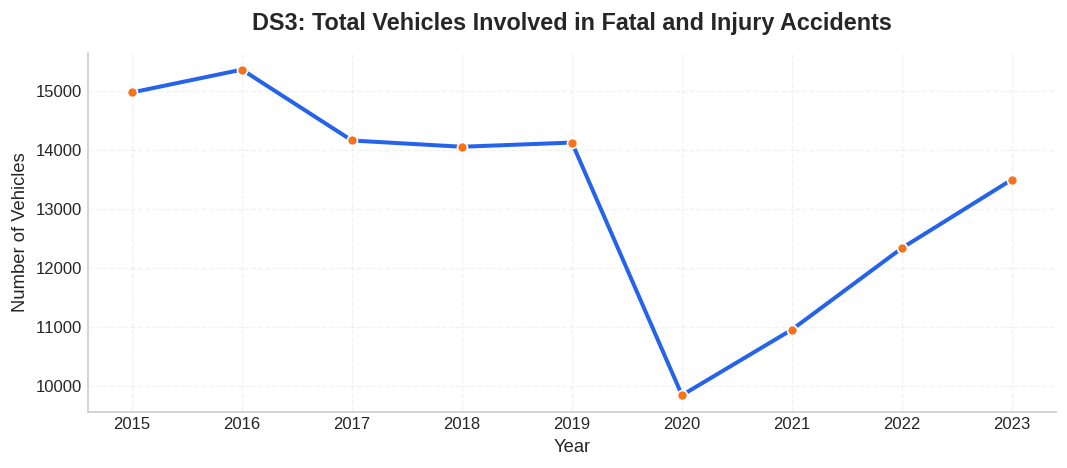

Saved: road_safety_deliverable2_outputs/ds3_long.csv


In [7]:
heading("DS3 PREPARATION")

year_cols_3 = [c for c in df3.columns if str(c).isdigit()]

df3_long = df3.melt(
    id_vars="DataSeries",
    value_vars=year_cols_3,
    var_name="year",
    value_name="value",
).copy()

df3_long["year"] = pd.to_numeric(df3_long["year"], errors="coerce")
df3_long["value"] = pd.to_numeric(df3_long["value"], errors="coerce")
df3_long = df3_long.dropna(subset=["year", "value"]).drop_duplicates()

profile_dataset(df3_long, "DS3 Long")

annual_total_vehicles_involved = df3_long[df3_long["DataSeries"] == "Total"].sort_values("year")
safe_display(annual_total_vehicles_involved, n=len(annual_total_vehicles_involved))

line_plot(
    annual_total_vehicles_involved["year"],
    annual_total_vehicles_involved["value"],
    "DS3: Total Vehicles Involved in Fatal and Injury Accidents",
    "Year",
    "Number of Vehicles",
    marker="o",
    figsize=(9, 4),
)

save_csv(df3_long, "ds3_long.csv")


## 10. DS4 Preparation - Monthly Rainfall

DS4 is already close to the required form. Cleaning mainly involves standardizing types and creating time attributes for integration.



DS4 PREPARATION

DS4 Clean - PROFILE
Shape: (528, 4)
Columns: ['month', 'total_rainfall', 'year', 'month_num']


,month,total_rainfall,year,month_num
0,1982-01-01,107.1,1982,1
1,1982-02-01,27.8,1982,2
2,1982-03-01,160.8,1982,3
3,1982-04-01,157.0,1982,4
4,1982-05-01,102.2,1982,5


,column,dtype,missing_count,missing_pct,distinct_values
0,month,datetime64[ns],0,0.0,528
1,total_rainfall,float64,0,0.0,490
2,year,int32,0,0.0,44
3,month_num,int32,0,0.0,12


,count,mean,min,25%,50%,75%,max,std
month,528,2003-12-16 11:00:00,1982-01-01 00:00:00,1992-12-24 06:00:00,2003-12-16 12:00:00,2014-12-08 18:00:00,2025-12-01 00:00:00,NaN
total_rainfall,528.0,180.041288,0.2,96.75,160.8,239.65,765.9,114.742194
year,528.0,2003.5,1982.0,1992.75,2003.5,2014.25,2025.0,12.710467
month_num,528.0,6.5,1.0,3.75,6.5,9.25,12.0,3.455326


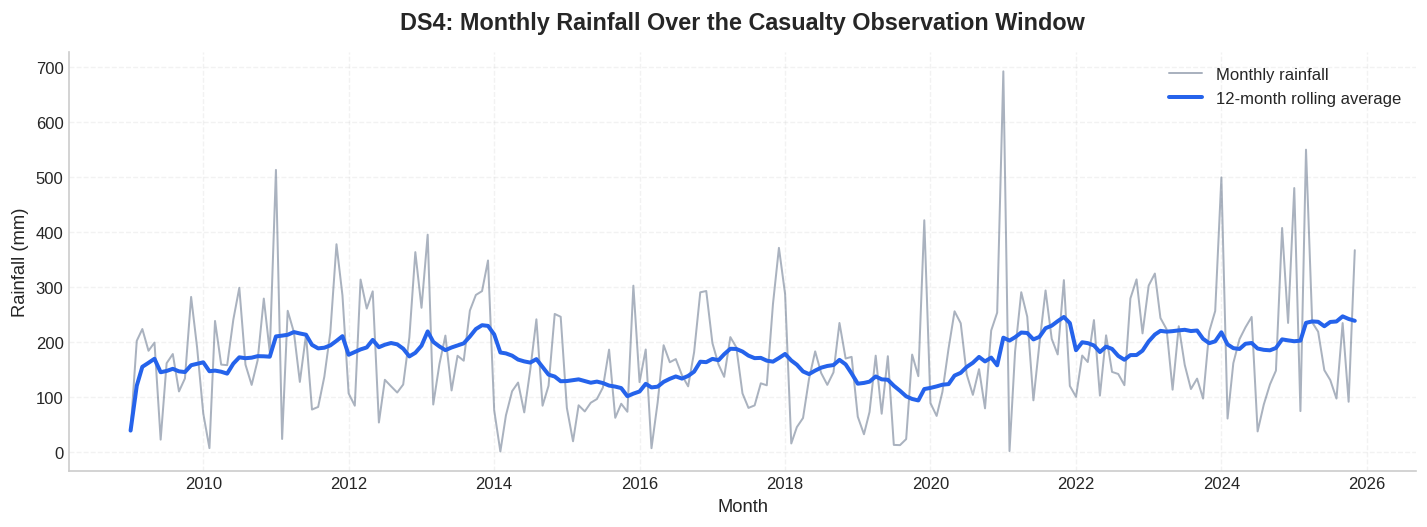

Saved: road_safety_deliverable2_outputs/ds4_clean.csv


In [8]:
heading("DS4 PREPARATION")

df4_clean = df4.copy()
df4_clean["month"] = pd.to_datetime(df4_clean["month"], format="%Y-%m", errors="coerce")
df4_clean["total_rainfall"] = pd.to_numeric(df4_clean["total_rainfall"], errors="coerce")
df4_clean = df4_clean.dropna(subset=["month", "total_rainfall"]).drop_duplicates().sort_values("month")
df4_clean["year"] = df4_clean["month"].dt.year
df4_clean["month_num"] = df4_clean["month"].dt.month

profile_dataset(df4_clean, "DS4 Clean")

df4_overlap = df4_clean[(df4_clean["month"] >= target_monthly["month"].min()) & (df4_clean["month"] <= target_monthly["month"].max())].copy()
df4_overlap["rainfall_12m_avg"] = df4_overlap["total_rainfall"].rolling(12, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(df4_overlap["month"], df4_overlap["total_rainfall"], color=NEUTRAL, linewidth=1.2, alpha=0.55, label="Monthly rainfall")
ax.plot(df4_overlap["month"], df4_overlap["rainfall_12m_avg"], color=SECONDARY, linewidth=2.4, label="12-month rolling average")
ax.set_title("DS4: Monthly Rainfall Over the Casualty Observation Window", pad=14, weight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Rainfall (mm)")
ax.grid(True, alpha=0.25, linestyle="--")
ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

save_csv(df4_clean, "ds4_clean.csv")


## 11. DS5 Preparation - Monthly Vehicle Population

DS5 is monthly and therefore a strong enrichment source. However, its category labels contain minor naming inconsistencies, so standardization is required before pivoting the dataset into a feature table.



DS5 PREPARATION

DS5 Clean - PROFILE
Shape: (444, 6)
Columns: ['month', 'vehicle_type', 'number', 'vehicle_slug', 'year', 'month_num']


,month,vehicle_type,number,vehicle_slug,year,month_num
3,2012-01-01,Buses,17037,buses,2012,1
0,2012-01-01,Cars,593555,cars,2012,1
4,2012-01-01,Goods & Other Vehicles,159854,goods_other_vehicles,2012,1
5,2012-01-01,Motorcycles,146388,motorcycles,2012,1
1,2012-01-01,Rental Cars,13970,rental_cars,2012,1


,column,dtype,missing_count,missing_pct,distinct_values
0,month,datetime64[ns],0,0.0,74
1,vehicle_type,object,0,0.0,8
2,number,int64,0,0.0,440
3,vehicle_slug,object,0,0.0,8
4,year,int32,0,0.0,7
5,month_num,int32,0,0.0,12


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
month,444,NaN,NaN,NaN,2015-01-15 17:50:16.216216320,2012-01-01 00:00:00,2013-07-01 00:00:00,2015-01-16 12:00:00,2016-08-01 00:00:00,2018-02-01 00:00:00,NaN
vehicle_type,444,8,Buses,74,NaN,NaN,NaN,NaN,NaN,NaN,NaN
number,444.0,NaN,NaN,NaN,160577.155405,13970.0,19371.25,104473.5,160561.25,607292.0,198119.328833
vehicle_slug,444,8,buses,74,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,444.0,NaN,NaN,NaN,2014.594595,2012.0,2013.0,2015.0,2016.0,2018.0,1.779636
month_num,444.0,NaN,NaN,NaN,6.364865,1.0,3.0,6.0,9.0,12.0,3.505202


,month,veh_buses,veh_car,veh_cars,veh_goods_other_vehicles,veh_motorcycle_and_scooter,veh_motorcycles,veh_rental_cars,veh_taxi,year,month_num,veh_cars_combined,veh_motorcycle_exposure
0,2012-01-01,17037.0,NaN,593555.0,159854.0,NaN,146388.0,13970.0,27059.0,2012,1,593555.0,146388.0
1,2012-02-01,17076.0,NaN,594925.0,160105.0,NaN,146397.0,14033.0,27163.0,2012,2,594925.0,146397.0
2,2012-03-01,17093.0,NaN,596098.0,160223.0,NaN,146316.0,14164.0,27266.0,2012,3,596098.0,146316.0
3,2012-04-01,17144.0,NaN,597000.0,160394.0,NaN,146024.0,14250.0,27618.0,2012,4,597000.0,146024.0
4,2012-05-01,17154.0,NaN,598018.0,160441.0,NaN,145963.0,14312.0,27733.0,2012,5,598018.0,145963.0


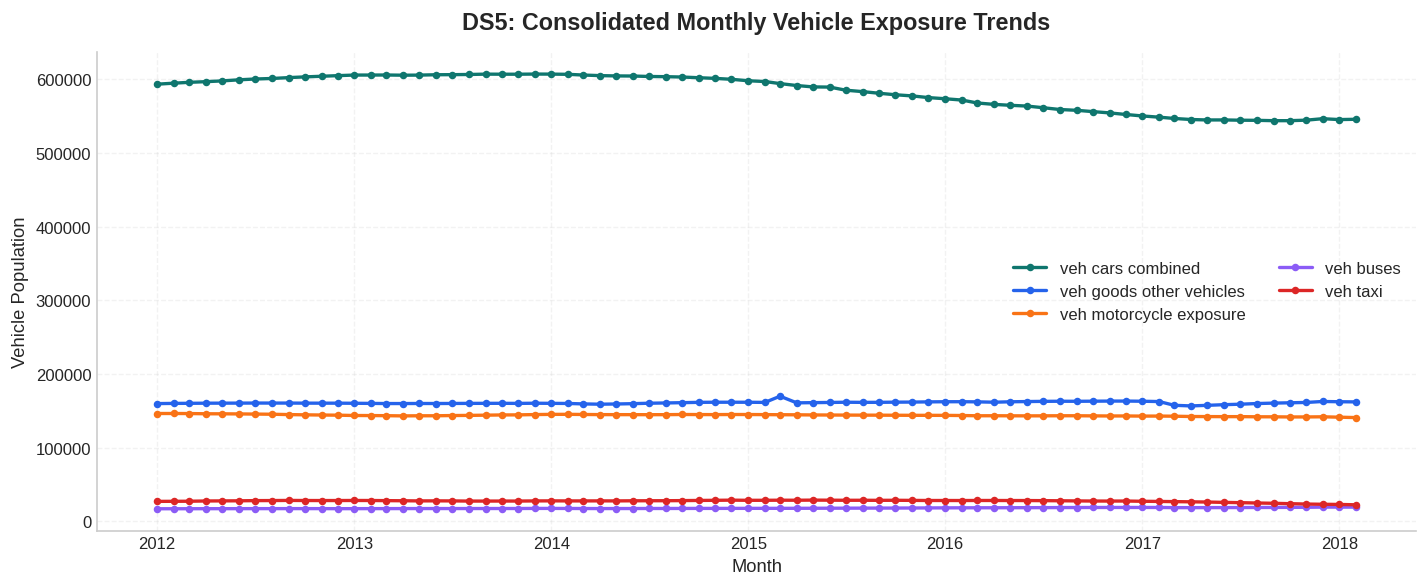

Saved: road_safety_deliverable2_outputs/ds5_clean.csv
Saved: road_safety_deliverable2_outputs/ds5_wide.csv


In [9]:
heading("DS5 PREPARATION")

df5_clean = df5.copy()
df5_clean["month"] = pd.to_datetime(df5_clean["month"], format="%Y-%m", errors="coerce")
df5_clean["vehicle_type"] = df5_clean["vehicle_type"].astype(str).str.strip().map(vehicle_type_standardize)
df5_clean["number"] = pd.to_numeric(df5_clean["number"], errors="coerce")
df5_clean = df5_clean.dropna(subset=["month", "vehicle_type", "number"]).drop_duplicates().sort_values(["month", "vehicle_type"])
df5_clean["vehicle_slug"] = df5_clean["vehicle_type"].map(slugify)
df5_clean["year"] = df5_clean["month"].dt.year
df5_clean["month_num"] = df5_clean["month"].dt.month

profile_dataset(df5_clean, "DS5 Clean")

df5_wide = (
    df5_clean.pivot_table(
        index="month",
        columns="vehicle_slug",
        values="number",
        aggfunc="sum",
    )
    .reset_index()
)
df5_wide.columns = ["month"] + [f"veh_{c}" for c in df5_wide.columns[1:]]
df5_wide["year"] = df5_wide["month"].dt.year
df5_wide["month_num"] = df5_wide["month"].dt.month

if {"veh_car", "veh_cars"}.issubset(df5_wide.columns):
    df5_wide["veh_cars_combined"] = df5_wide[["veh_cars", "veh_car"]].bfill(axis=1).iloc[:, 0]
elif "veh_cars" in df5_wide.columns:
    df5_wide["veh_cars_combined"] = df5_wide["veh_cars"]
elif "veh_car" in df5_wide.columns:
    df5_wide["veh_cars_combined"] = df5_wide["veh_car"]

if {"veh_motorcycle_and_scooter", "veh_motorcycles"}.issubset(df5_wide.columns):
    df5_wide["veh_motorcycle_exposure"] = df5_wide[["veh_motorcycles", "veh_motorcycle_and_scooter"]].bfill(axis=1).iloc[:, 0]
elif "veh_motorcycles" in df5_wide.columns:
    df5_wide["veh_motorcycle_exposure"] = df5_wide["veh_motorcycles"]
elif "veh_motorcycle_and_scooter" in df5_wide.columns:
    df5_wide["veh_motorcycle_exposure"] = df5_wide["veh_motorcycle_and_scooter"]

safe_display(df5_wide, n=5)

plot_cols = [c for c in ["veh_cars_combined", "veh_goods_other_vehicles", "veh_motorcycle_exposure", "veh_buses", "veh_taxi"] if c in df5_wide.columns]
fig, ax = plt.subplots(figsize=(12, 5))
color_cycle = [PRIMARY, SECONDARY, ACCENT, "#8b5cf6", "#dc2626"]
for col, color in zip(plot_cols, color_cycle):
    ax.plot(df5_wide["month"], df5_wide[col], marker="o", markersize=3.5, linewidth=2.0, label=clean_label(col, 18).replace(chr(10), " "), color=color)
ax.set_title("DS5: Consolidated Monthly Vehicle Exposure Trends", pad=14, weight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Vehicle Population")
ax.grid(True, alpha=0.25, linestyle="--")
ax.legend(frameon=False, ncol=2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

save_csv(df5_clean, "ds5_clean.csv")
save_csv(df5_wide, "ds5_wide.csv")


## 12. Data Enrichment and Integration (Process)

This section implements the core **Process** stage of the pipeline.

The final analytical table is built at a **monthly granularity** so that all core sources can be aligned on a shared time key:
- **DS2** provides the target casualty series,
- **DS4** provides rainfall enrichment,
- **DS5** provides vehicle-population exposure features.

An inner join is used for the DS5 merge so that the final table only retains months that are available across all core sources. As a result, the integrated analytical table is restricted to the shared monthly period rather than the full raw DS2 time span.


In [10]:
heading("DATA ENRICHMENT AND INTEGRATION")

monthly_analytic = (
    target_monthly
    .merge(df4_clean[["month", "total_rainfall"]], on="month", how="left")
    .merge(df5_wide, on="month", how="inner")
    .sort_values("month")
    .reset_index(drop=True)
)

monthly_analytic["year"] = monthly_analytic["month"].dt.year
monthly_analytic["month_num"] = monthly_analytic["month"].dt.month
monthly_analytic["quarter"] = monthly_analytic["month"].dt.quarter
monthly_analytic["rainfall_level"] = pd.cut(
    monthly_analytic["total_rainfall"],
    bins=[-np.inf, 100, 200, np.inf],
    labels=["Low", "Moderate", "High"],
)
monthly_analytic["is_year_end"] = monthly_analytic["month_num"].isin([11, 12]).astype(int)

print("Integrated monthly period:", monthly_analytic["month"].min(), "to", monthly_analytic["month"].max())
print("Rows:", len(monthly_analytic))

safe_display(monthly_analytic, n=10)

save_csv(monthly_analytic, "monthly_analytic.csv")



DATA ENRICHMENT AND INTEGRATION
Integrated monthly period: 2012-01-01 00:00:00 to 2018-02-01 00:00:00
Rows: 74


,month,year_x,month_num_x,fatalities,injured,total_casualties,fatality_rate_pct,total_rainfall,veh_buses,veh_car,veh_cars,veh_goods_other_vehicles,veh_motorcycle_and_scooter,veh_motorcycles,veh_rental_cars,veh_taxi,year_y,month_num_y,veh_cars_combined,veh_motorcycle_exposure,year,month_num,quarter,rainfall_level,is_year_end
0,2012-01-01,2012,1,17.0,855.0,872.0,1.95,106.1,17037.0,NaN,593555.0,159854.0,NaN,146388.0,13970.0,27059.0,2012,1,593555.0,146388.0,2012,1,1,Moderate,0
1,2012-02-01,2012,2,17.0,900.0,917.0,1.85,83.6,17076.0,NaN,594925.0,160105.0,NaN,146397.0,14033.0,27163.0,2012,2,594925.0,146397.0,2012,2,1,Low,0
2,2012-03-01,2012,3,15.0,910.0,925.0,1.62,313.4,17093.0,NaN,596098.0,160223.0,NaN,146316.0,14164.0,27266.0,2012,3,596098.0,146316.0,2012,3,1,High,0
3,2012-04-01,2012,4,15.0,829.0,844.0,1.78,260.6,17144.0,NaN,597000.0,160394.0,NaN,146024.0,14250.0,27618.0,2012,4,597000.0,146024.0,2012,4,2,High,0
4,2012-05-01,2012,5,11.0,889.0,900.0,1.22,292.0,17154.0,NaN,598018.0,160441.0,NaN,145963.0,14312.0,27733.0,2012,5,598018.0,145963.0,2012,5,2,High,0
5,2012-06-01,2012,6,10.0,701.0,711.0,1.41,53.0,17190.0,NaN,599493.0,160492.0,NaN,145819.0,14349.0,27849.0,2012,6,599493.0,145819.0,2012,6,2,Low,0
6,2012-07-01,2012,7,9.0,899.0,908.0,0.99,130.8,17217.0,NaN,600598.0,160580.0,NaN,145605.0,14430.0,28101.0,2012,7,600598.0,145605.0,2012,7,3,Moderate,0
7,2012-08-01,2012,8,15.0,897.0,912.0,1.64,119.0,17214.0,NaN,601298.0,160555.0,NaN,145388.0,14540.0,28176.0,2012,8,601298.0,145388.0,2012,8,3,Moderate,0
8,2012-09-01,2012,9,11.0,871.0,882.0,1.25,107.6,17238.0,NaN,602481.0,160551.0,NaN,144923.0,14585.0,28364.0,2012,9,602481.0,144923.0,2012,9,3,Moderate,0
9,2012-10-01,2012,10,15.0,847.0,862.0,1.74,122.2,17241.0,NaN,603460.0,160440.0,NaN,144588.0,14664.0,28243.0,2012,10,603460.0,144588.0,2012,10,4,Moderate,0


Saved: road_safety_deliverable2_outputs/monthly_analytic.csv


## 13. Final Dataset Profiling

After integration, the final analytical dataset is profiled again to verify that the transformations produced a coherent analysis-ready table.


In [11]:
profile_monthly_analytic = profile_dataset(monthly_analytic, "Monthly Analytical Dataset")



Monthly Analytical Dataset - PROFILE
Shape: (74, 25)
Columns: ['month', 'year_x', 'month_num_x', 'fatalities', 'injured', 'total_casualties', 'fatality_rate_pct', 'total_rainfall', 'veh_buses', 'veh_car', 'veh_cars', 'veh_goods_other_vehicles', 'veh_motorcycle_and_scooter', 'veh_motorcycles', 'veh_rental_cars', 'veh_taxi', 'year_y', 'month_num_y', 'veh_cars_combined', 'veh_motorcycle_exposure', 'year', 'month_num', 'quarter', 'rainfall_level', 'is_year_end']


,month,year_x,month_num_x,fatalities,injured,total_casualties,fatality_rate_pct,total_rainfall,veh_buses,veh_car,veh_cars,veh_goods_other_vehicles,veh_motorcycle_and_scooter,veh_motorcycles,veh_rental_cars,veh_taxi,year_y,month_num_y,veh_cars_combined,veh_motorcycle_exposure,year,month_num,quarter,rainfall_level,is_year_end
0,2012-01-01,2012,1,17.0,855.0,872.0,1.95,106.1,17037.0,NaN,593555.0,159854.0,NaN,146388.0,13970.0,27059.0,2012,1,593555.0,146388.0,2012,1,1,Moderate,0
1,2012-02-01,2012,2,17.0,900.0,917.0,1.85,83.6,17076.0,NaN,594925.0,160105.0,NaN,146397.0,14033.0,27163.0,2012,2,594925.0,146397.0,2012,2,1,Low,0
2,2012-03-01,2012,3,15.0,910.0,925.0,1.62,313.4,17093.0,NaN,596098.0,160223.0,NaN,146316.0,14164.0,27266.0,2012,3,596098.0,146316.0,2012,3,1,High,0
3,2012-04-01,2012,4,15.0,829.0,844.0,1.78,260.6,17144.0,NaN,597000.0,160394.0,NaN,146024.0,14250.0,27618.0,2012,4,597000.0,146024.0,2012,4,2,High,0
4,2012-05-01,2012,5,11.0,889.0,900.0,1.22,292.0,17154.0,NaN,598018.0,160441.0,NaN,145963.0,14312.0,27733.0,2012,5,598018.0,145963.0,2012,5,2,High,0


,column,dtype,missing_count,missing_pct,distinct_values
9,veh_car,float64,67,90.54,7
12,veh_motorcycle_and_scooter,float64,67,90.54,7
10,veh_cars,float64,7,9.46,67
13,veh_motorcycles,float64,7,9.46,65
0,month,datetime64[ns],0,0.00,74
1,year_x,int32,0,0.00,7
2,month_num_x,int32,0,0.00,12
3,fatalities,float64,0,0.00,15
4,injured,float64,0,0.00,64
5,total_casualties,float64,0,0.00,60


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
month,74,NaN,NaN,NaN,2015-01-15 17:50:16.216216320,2012-01-01 00:00:00,2013-07-08 18:00:00,2015-01-16 12:00:00,2016-07-24 06:00:00,2018-02-01 00:00:00,NaN
year_x,74.0,NaN,NaN,NaN,2014.594595,2012.0,2013.0,2015.0,2016.0,2018.0,1.789765
month_num_x,74.0,NaN,NaN,NaN,6.364865,1.0,3.0,6.0,9.0,12.0,3.525152
fatalities,74.0,NaN,NaN,NaN,12.405405,3.0,10.0,12.0,15.0,20.0,3.343032
injured,74.0,NaN,NaN,NaN,845.256757,666.0,811.25,845.5,887.0,1025.0,61.459656
total_casualties,74.0,NaN,NaN,NaN,857.662162,684.0,823.5,862.5,896.5,1037.0,61.076928
fatality_rate_pct,74.0,NaN,NaN,NaN,1.456622,0.37,1.18,1.455,1.69,2.63,0.420942
total_rainfall,74.0,NaN,NaN,NaN,162.390541,0.2,87.65,133.5,233.6,395.2,93.505158
veh_buses,74.0,NaN,NaN,NaN,17887.486486,17037.0,17322.75,17599.5,18561.0,19285.0,673.118367
veh_car,7.0,NaN,NaN,NaN,545039.571429,543991.0,544238.0,544708.0,545698.0,546706.0,1027.653939


## 14. Descriptive Analytics

In line with the SC3021 analytics lectures, this section performs descriptive analysis through summary statistics, aggregation, visualization, and time-series inspection.



DESCRIPTIVE ANALYTICS


,year,total_casualties,fatalities,injured,yoy_pct_change
0,2009,11069.0,183.0,10886.0,NaN
1,2010,11521.0,193.0,11328.0,4.08
2,2011,10806.0,195.0,10611.0,-6.21
3,2012,10421.0,168.0,10253.0,-3.56
4,2013,9911.0,160.0,9751.0,-4.89
5,2014,10013.0,155.0,9858.0,1.03
6,2015,10563.0,151.0,10412.0,5.49
7,2016,10828.0,141.0,10687.0,2.51
8,2017,10074.0,121.0,9953.0,-6.96
9,2018,10142.0,124.0,10018.0,0.68


,month_num,total_casualties
0,1,847.06
1,2,751.76
2,3,818.65
3,4,802.88
4,5,800.94
5,6,770.41
6,7,843.82
7,8,851.76
8,9,810.71
9,10,842.18


,rainfall_level,count,mean,median,min,max
0,Low,22,838.05,840.5,684.0,970.0
1,Moderate,30,866.13,870.5,719.0,1037.0
2,High,22,865.73,857.0,776.0,989.0


,month,total_casualties,fatalities,fatality_rate_pct
19,2010-08-01,1075.0,20.0,1.86
21,2010-10-01,1053.0,13.0,1.23
18,2010-07-01,1043.0,16.0,1.53
91,2016-08-01,1037.0,12.0,1.16
16,2010-05-01,1030.0,18.0,1.75
83,2015-12-01,989.0,11.0,1.11
20,2010-09-01,984.0,14.0,1.42
7,2009-08-01,980.0,14.0,1.43
24,2011-01-01,976.0,20.0,2.05
14,2010-03-01,973.0,23.0,2.36


,month,total_casualties,fatalities,fatality_rate_pct
136,2020-05-01,306.0,2.0,0.65
135,2020-04-01,349.0,11.0,3.15
137,2020-06-01,429.0,7.0,1.63
153,2021-10-01,512.0,6.0,1.17
139,2020-08-01,523.0,10.0,1.91
157,2022-02-01,531.0,6.0,1.13
138,2020-07-01,557.0,3.0,0.54
148,2021-05-01,565.0,12.0,2.12
145,2021-02-01,576.0,12.0,2.08
158,2022-03-01,577.0,11.0,1.91


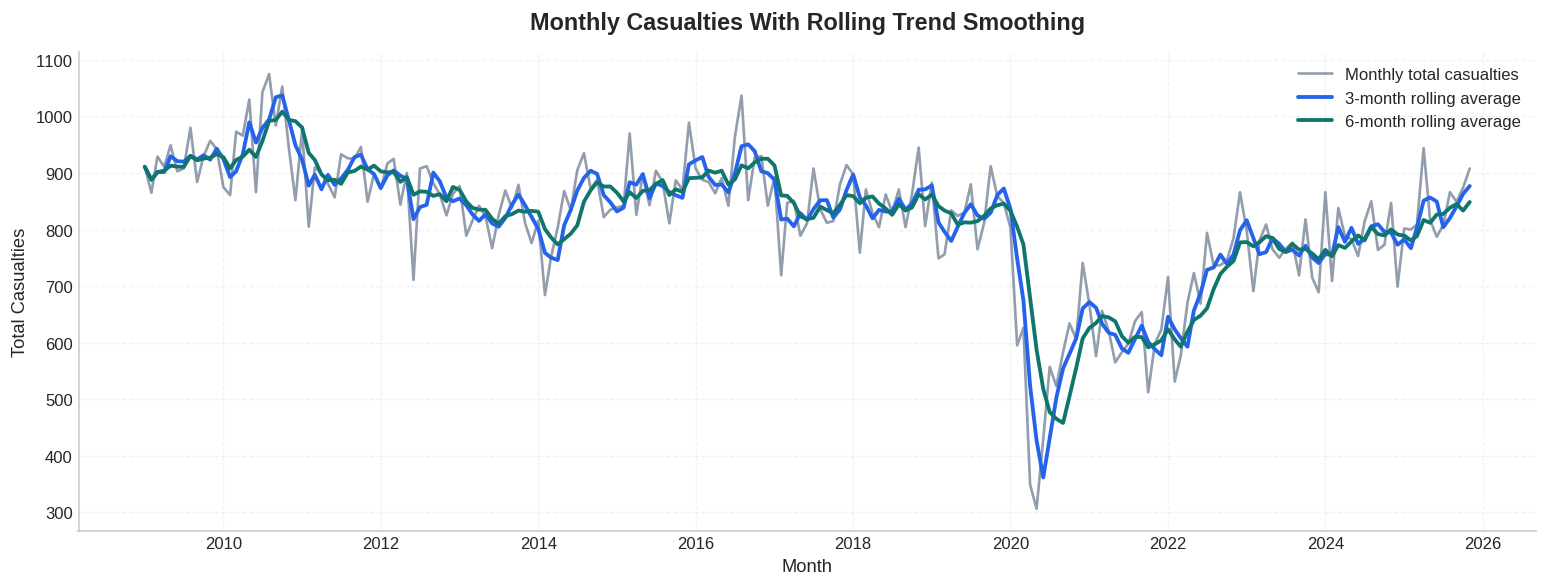

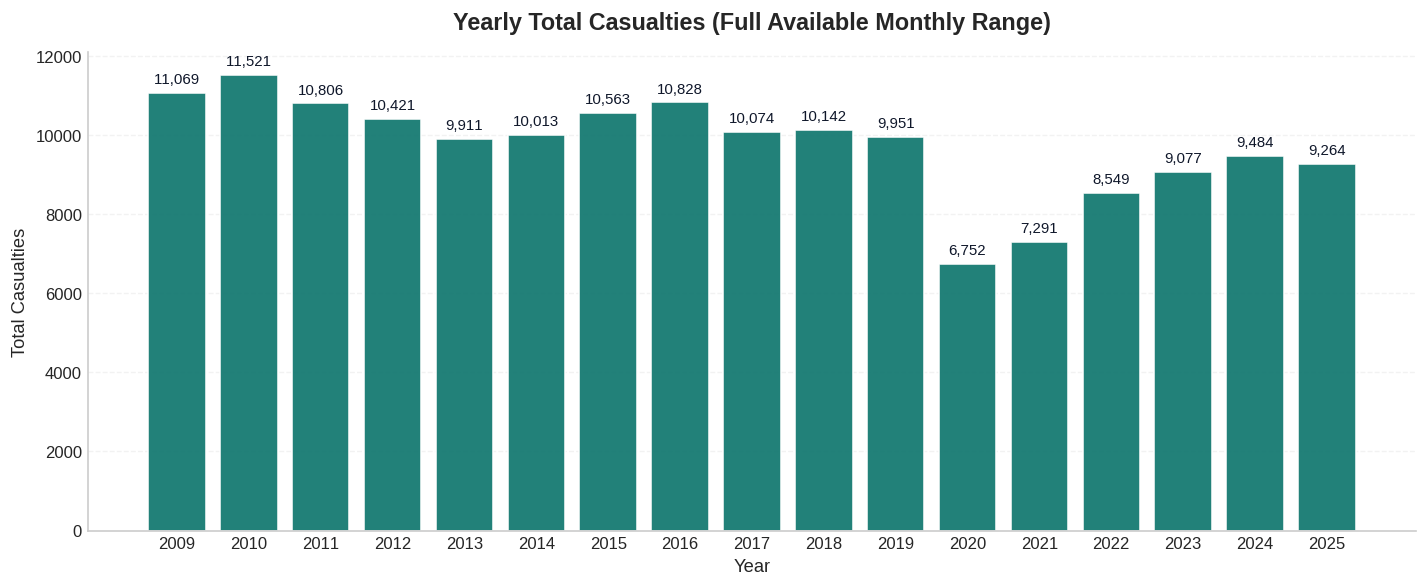

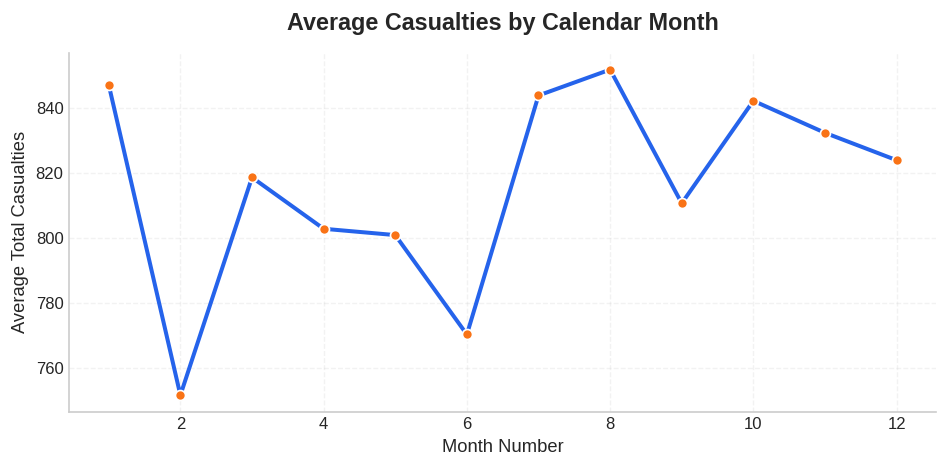

Saved: road_safety_deliverable2_outputs/yearly_target_full.csv
Saved: road_safety_deliverable2_outputs/monthnum_target.csv
Saved: road_safety_deliverable2_outputs/rain_bucket_summary.csv
Saved: road_safety_deliverable2_outputs/peak_months.csv
Saved: road_safety_deliverable2_outputs/low_months.csv


In [12]:
heading("DESCRIPTIVE ANALYTICS")

target_monthly_full = target_monthly.sort_values("month").copy()
target_monthly_full["rolling_avg_3m"] = target_monthly_full["total_casualties"].rolling(3, min_periods=1).mean()
target_monthly_full["rolling_avg_6m"] = target_monthly_full["total_casualties"].rolling(6, min_periods=1).mean()

yearly_target_full = (
    target_monthly_full.groupby("year", as_index=False)[["total_casualties", "fatalities", "injured"]]
    .sum()
    .sort_values("year")
)
yearly_target_full["yoy_pct_change"] = yearly_target_full["total_casualties"].pct_change().mul(100).round(2)

monthnum_target = target_monthly_full.groupby("month_num", as_index=False)["total_casualties"].mean().round(2)
rain_bucket_summary = (
    monthly_analytic.groupby("rainfall_level", observed=False)["total_casualties"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
    .reset_index()
)

peak_months = target_monthly_full.nlargest(10, "total_casualties")[["month", "total_casualties", "fatalities", "fatality_rate_pct"]]
low_months = target_monthly_full.nsmallest(10, "total_casualties")[["month", "total_casualties", "fatalities", "fatality_rate_pct"]]

safe_display(yearly_target_full, n=len(yearly_target_full))
safe_display(monthnum_target, n=len(monthnum_target))
safe_display(rain_bucket_summary, n=len(rain_bucket_summary))
safe_display(peak_months, n=len(peak_months))
safe_display(low_months, n=len(low_months))

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(target_monthly_full["month"], target_monthly_full["total_casualties"], color=NEUTRAL, linewidth=1.6, alpha=0.7, label="Monthly total casualties")
ax.plot(target_monthly_full["month"], target_monthly_full["rolling_avg_3m"], color=SECONDARY, linewidth=2.3, label="3-month rolling average")
ax.plot(target_monthly_full["month"], target_monthly_full["rolling_avg_6m"], color=PRIMARY, linewidth=2.3, label="6-month rolling average")
ax.set_title("Monthly Casualties With Rolling Trend Smoothing", pad=14, weight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Total Casualties")
ax.grid(True, alpha=0.25, linestyle="--")
ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

bar_plot(
    yearly_target_full["year"].astype(str),
    yearly_target_full["total_casualties"],
    "Yearly Total Casualties (Full Available Monthly Range)",
    "Year",
    "Total Casualties",
    figsize=(12, 5),
    color=PRIMARY,
)

line_plot(
    monthnum_target["month_num"],
    monthnum_target["total_casualties"],
    "Average Casualties by Calendar Month",
    "Month Number",
    "Average Total Casualties",
    marker="o",
    figsize=(8, 4),
    color=SECONDARY,
)

save_csv(yearly_target_full, "yearly_target_full.csv")
save_csv(monthnum_target, "monthnum_target.csv")
save_csv(rain_bucket_summary, "rain_bucket_summary.csv")
save_csv(peak_months, "peak_months.csv")
save_csv(low_months, "low_months.csv")


## 16. Seasonality, Composition, and Anomaly Analysis

This section extends the analysis beyond simple summary statistics. It focuses on three technical goals: identifying temporal seasonality, examining composition patterns across casualty categories, and detecting months that deviate strongly from the underlying trend. These are standard data-understanding tasks that go beyond a basic exploratory summary while still fitting Deliverable 2.



SEASONALITY, COMPOSITION, AND ANOMALY ANALYSIS


month_num,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2009,911.0,865.0,929.0,911.0,949.0,903.0,908.0,980.0,884.0,930.0,957.0,942.0
2010,875.0,861.0,973.0,966.0,1030.0,866.0,1043.0,1075.0,984.0,1053.0,943.0,852.0
2011,976.0,805.0,910.0,899.0,881.0,857.0,933.0,926.0,925.0,946.0,849.0,899.0
2012,872.0,917.0,925.0,844.0,900.0,711.0,908.0,912.0,882.0,862.0,825.0,863.0
2013,877.0,789.0,815.0,842.0,823.0,767.0,825.0,869.0,838.0,879.0,811.0,776.0
2014,816.0,684.0,751.0,803.0,868.0,834.0,905.0,935.0,872.0,888.0,822.0,835.0
2015,839.0,842.0,970.0,826.0,898.0,843.0,904.0,884.0,811.0,887.0,870.0,989.0
2016,908.0,888.0,884.0,864.0,891.0,842.0,963.0,1037.0,852.0,927.0,930.0,842.0
2017,892.0,719.0,847.0,851.0,789.0,811.0,908.0,836.0,812.0,815.0,880.0,914.0


,dataseries,category_casualties
7,Motor Cyclists & Pillion Riders,79799.0
6,Motor Cars And Station Wagons,41541.0
9,Pedestrians,15965.0
1,Cyclists & Pillions,9887.0
5,"Lorries, Tipper Trucks & Trailers",8529.0


,year,dataseries,category_casualties
0,2009,Cyclists & Pillions,586.0
1,2009,"Lorries, Tipper Trucks & Trailers",480.0
2,2009,Motor Cars And Station Wagons,2806.0
3,2009,Motor Cyclists & Pillion Riders,5396.0
4,2009,Pedestrians,1118.0
5,2010,Cyclists & Pillions,578.0
6,2010,"Lorries, Tipper Trucks & Trailers",589.0
7,2010,Motor Cars And Station Wagons,2853.0
8,2010,Motor Cyclists & Pillion Riders,5579.0
9,2010,Pedestrians,1112.0


,month,total_casualties,rolling_avg_6m,deviation_from_6m_avg
135,2020-04-01,349.0,679.833333,-330.833333
136,2020-05-01,306.0,587.666667,-281.666667
133,2020-02-01,595.0,804.666667,-209.666667
41,2012-06-01,711.0,861.500000,-150.500000
134,2020-03-01,626.0,773.666667,-147.666667
97,2017-02-01,719.0,860.333333,-141.333333
23,2010-12-01,852.0,991.666667,-139.666667
143,2020-12-01,741.0,607.333333,133.666667
162,2022-07-01,794.0,660.666667,133.333333
25,2011-02-01,805.0,935.500000,-130.500000


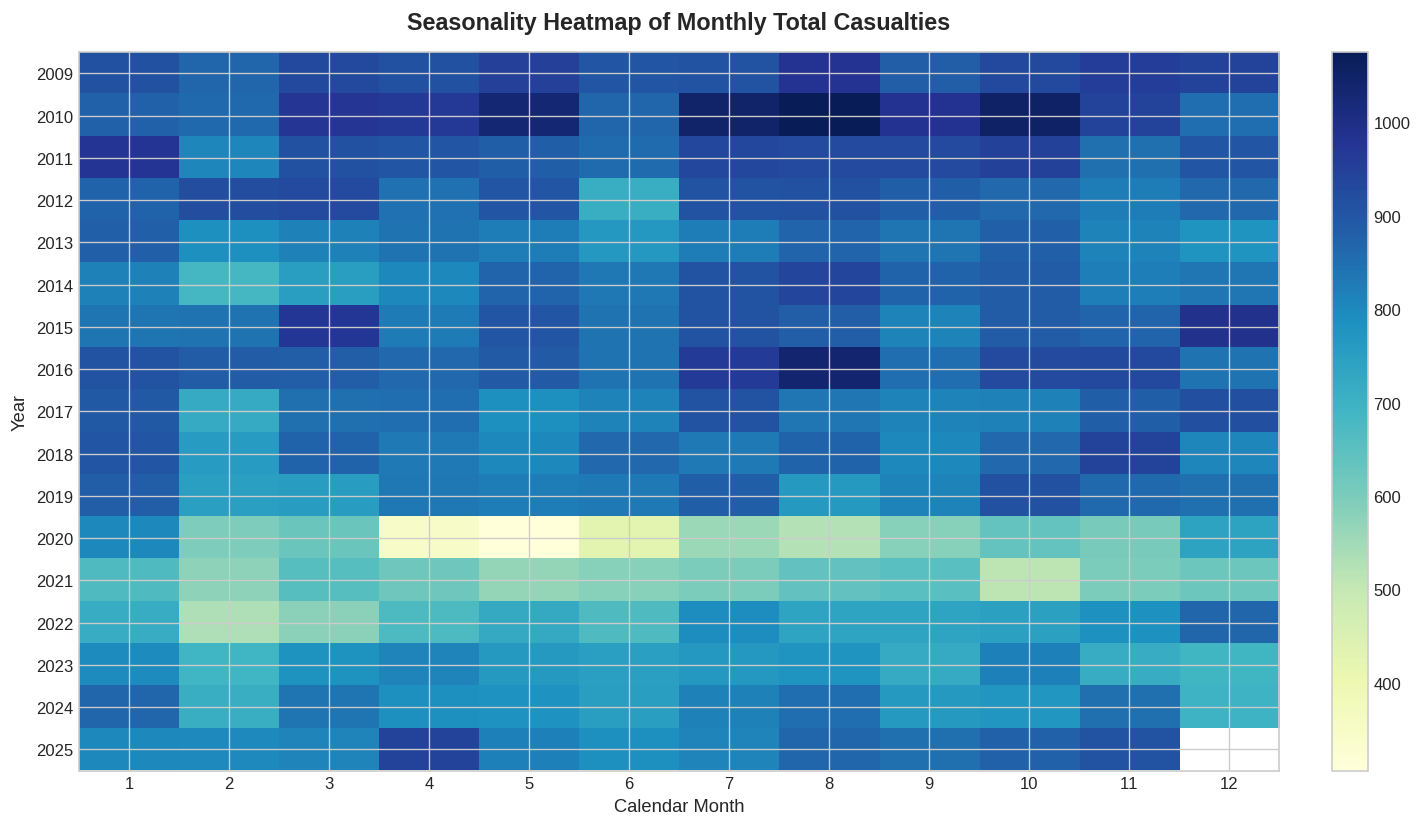

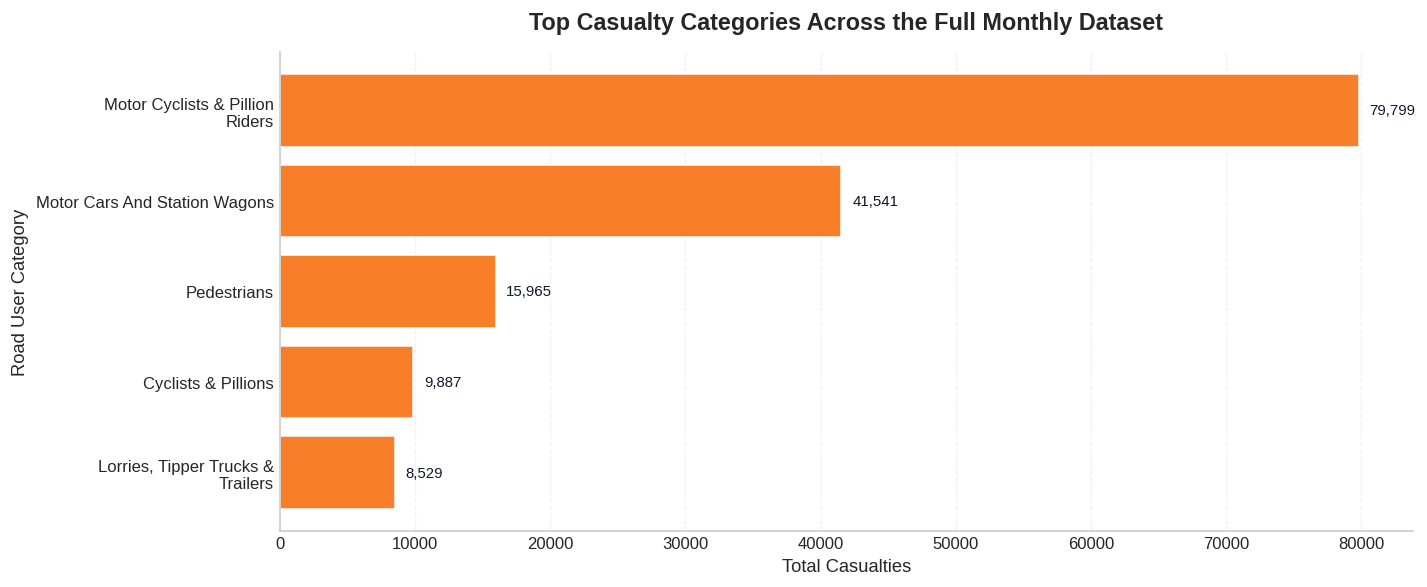

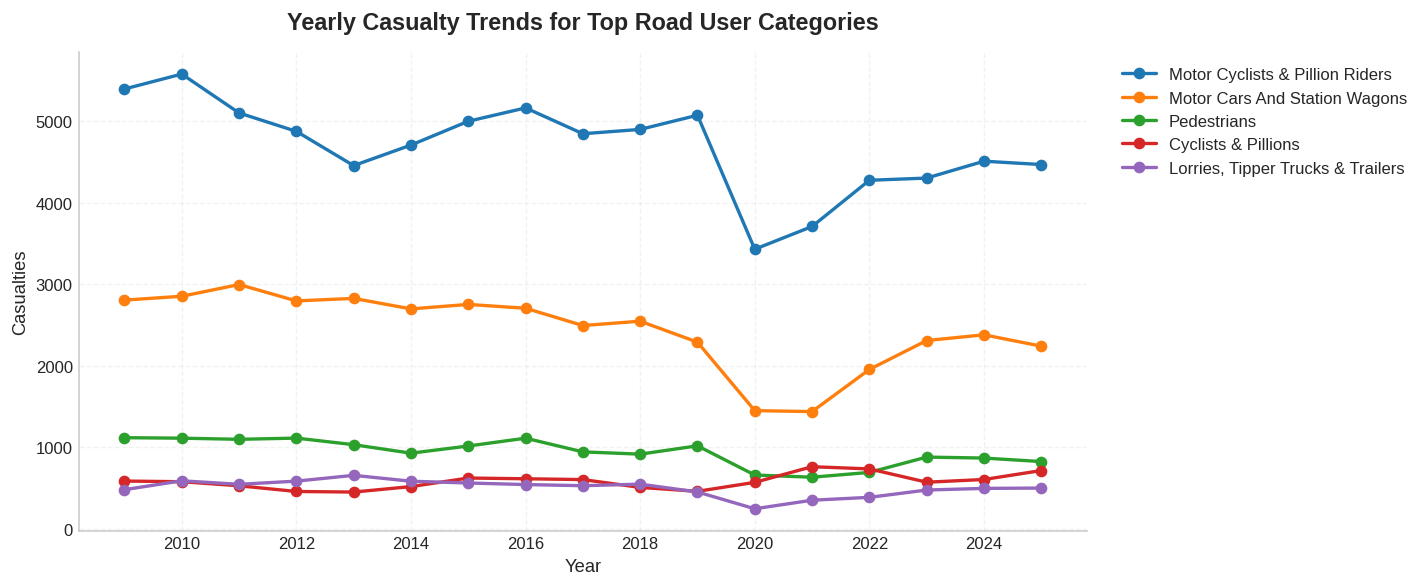

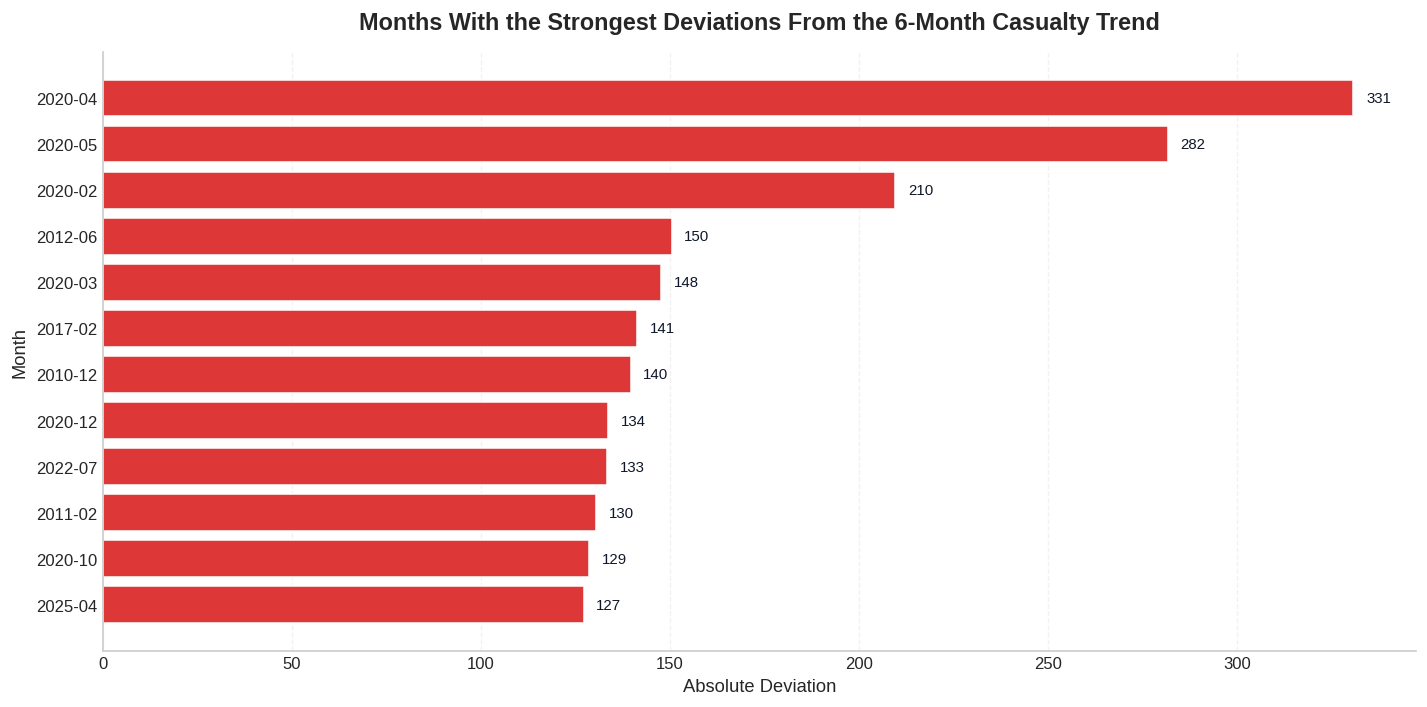

Saved: road_safety_deliverable2_outputs/seasonality_matrix.csv
Saved: road_safety_deliverable2_outputs/top_categories_full_period.csv
Saved: road_safety_deliverable2_outputs/category_yearly_trends.csv
Saved: road_safety_deliverable2_outputs/strongest_anomalies.csv


In [13]:
heading("SEASONALITY, COMPOSITION, AND ANOMALY ANALYSIS")

seasonality_matrix = (
    target_monthly_full.assign(year=target_monthly_full["month"].dt.year, month_num=target_monthly_full["month"].dt.month)
    .pivot(index="year", columns="month_num", values="total_casualties")
    .sort_index()
)

category_monthly = df2_long[~df2_long["dataseries"].str.startswith("Total Casualties")].copy()
category_monthly = (
    category_monthly.groupby(["month", "year", "dataseries"], as_index=False)["value"]
    .sum()
    .rename(columns={"value": "category_casualties"})
)
top_categories = (
    category_monthly.groupby("dataseries", as_index=False)["category_casualties"]
    .sum()
    .sort_values("category_casualties", ascending=False)
    .head(5)
)
category_yearly = (
    category_monthly[category_monthly["dataseries"].isin(top_categories["dataseries"])]
    .groupby(["year", "dataseries"], as_index=False)["category_casualties"]
    .sum()
)

anomaly_df = target_monthly_full.copy()
anomaly_df["deviation_from_6m_avg"] = anomaly_df["total_casualties"] - anomaly_df["rolling_avg_6m"]
anomaly_df["abs_deviation"] = anomaly_df["deviation_from_6m_avg"].abs()
strongest_anomalies = anomaly_df.nlargest(12, "abs_deviation")[["month", "total_casualties", "rolling_avg_6m", "deviation_from_6m_avg"]]

safe_display(seasonality_matrix, n=len(seasonality_matrix))
safe_display(top_categories, n=len(top_categories))
safe_display(category_yearly, n=len(category_yearly))
safe_display(strongest_anomalies, n=len(strongest_anomalies))

fig, ax = plt.subplots(figsize=(12, 7))
im = ax.imshow(seasonality_matrix, aspect="auto", cmap="YlGnBu")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_xticks(range(len(seasonality_matrix.columns)))
ax.set_xticklabels([clean_label(m, 8) for m in seasonality_matrix.columns])
ax.set_yticks(range(len(seasonality_matrix.index)))
ax.set_yticklabels(seasonality_matrix.index)
ax.set_title("Seasonality Heatmap of Monthly Total Casualties", pad=14, weight="bold")
ax.set_xlabel("Calendar Month")
ax.set_ylabel("Year")
plt.tight_layout()
plt.show()

bar_plot(
    top_categories["dataseries"],
    top_categories["category_casualties"],
    "Top Casualty Categories Across the Full Monthly Dataset",
    "Total Casualties",
    "Road User Category",
    figsize=(12, 5),
    horizontal=True,
    color=ACCENT,
)

fig, ax = plt.subplots(figsize=(12, 5))
for category in top_categories["dataseries"]:
    temp = category_yearly[category_yearly["dataseries"] == category].sort_values("year")
    ax.plot(temp["year"], temp["category_casualties"], marker="o", linewidth=2.0, label=category)
ax.set_title("Yearly Casualty Trends for Top Road User Categories", pad=14, weight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Casualties")
ax.grid(True, alpha=0.25, linestyle="--")
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

bar_plot(
    strongest_anomalies["month"].dt.strftime("%Y-%m"),
    strongest_anomalies["deviation_from_6m_avg"].abs(),
    "Months With the Strongest Deviations From the 6-Month Casualty Trend",
    "Absolute Deviation",
    "Month",
    figsize=(12, 6),
    horizontal=True,
    color=NEGATIVE,
)

save_csv(seasonality_matrix.reset_index(), "seasonality_matrix.csv")
save_csv(top_categories, "top_categories_full_period.csv")
save_csv(category_yearly, "category_yearly_trends.csv")
save_csv(strongest_anomalies, "strongest_anomalies.csv")


## 17. Dependency and Association Analysis

This section strengthens the **diagnostic** component of the notebook. The analysis focuses on relationships between total casualties and explanatory variables such as rainfall, lagged rainfall, calendar position, and vehicle-exposure indicators.

To keep the interpretation methodologically cautious, the results are framed as **association analysis** rather than as proof of causation.



DEPENDENCY AND ASSOCIATION ANALYSIS


,feature,pearson_corr_with_total_casualties
0,veh_goods_other_vehicles,0.405876
1,quarter,0.222993
2,total_rainfall,0.208706
3,rainfall_lag_1,-0.181966
4,month_num,0.173829
5,veh_cars_combined,-0.146102
6,veh_buses,0.132466
7,veh_taxi,0.120095
8,veh_motorcycle_exposure,0.036966


,rainfall_level,avg_casualties,avg_fatality_rate,avg_fatalities,months
0,Low,838.05,1.58,13.09,22
1,Moderate,866.13,1.37,11.87,30
2,High,865.73,1.45,12.45,22


,motorcycle_exposure_band,avg_total_casualties,avg_fatality_rate,avg_rainfall
0,Higher motorcycle exposure,852.84,1.53,153.68
1,Lower motorcycle exposure,862.49,1.38,171.10


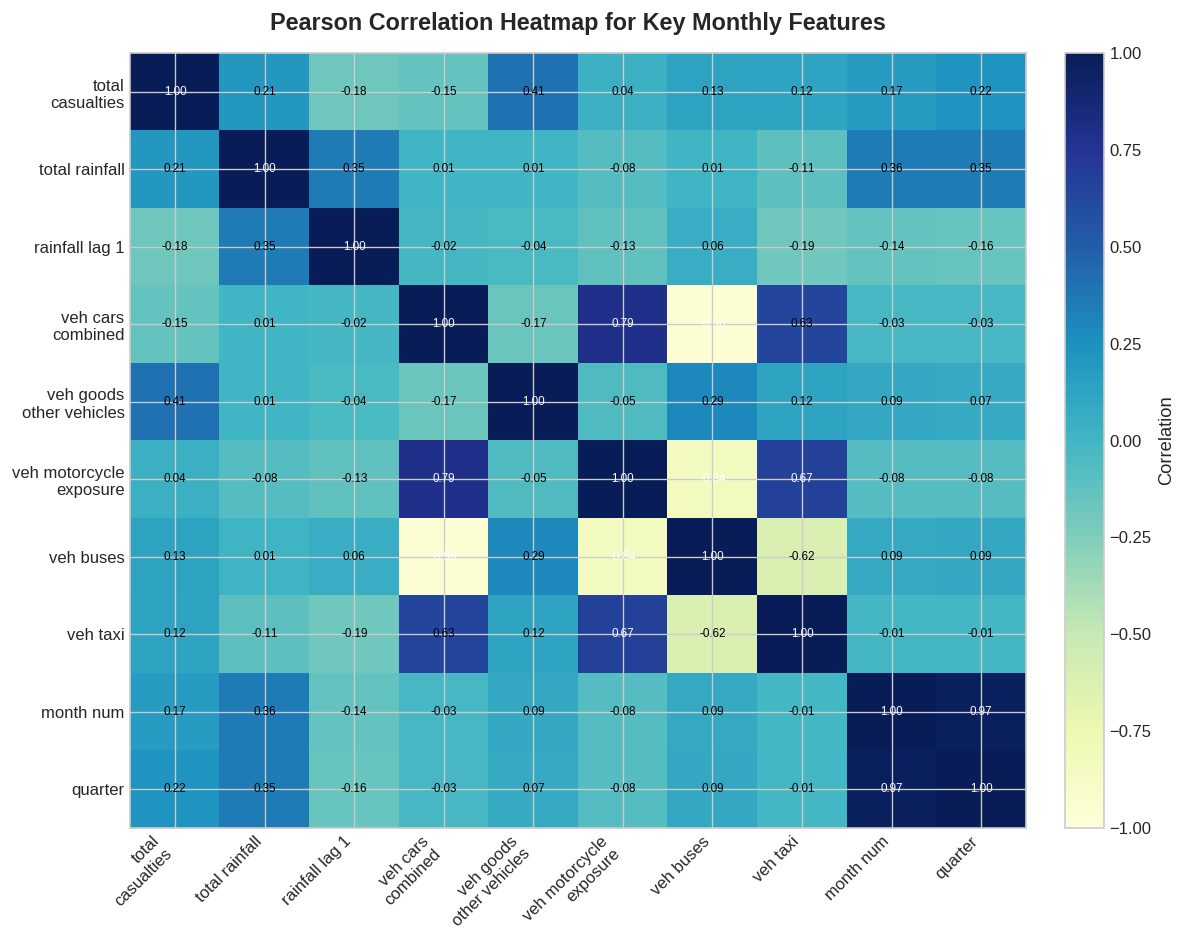

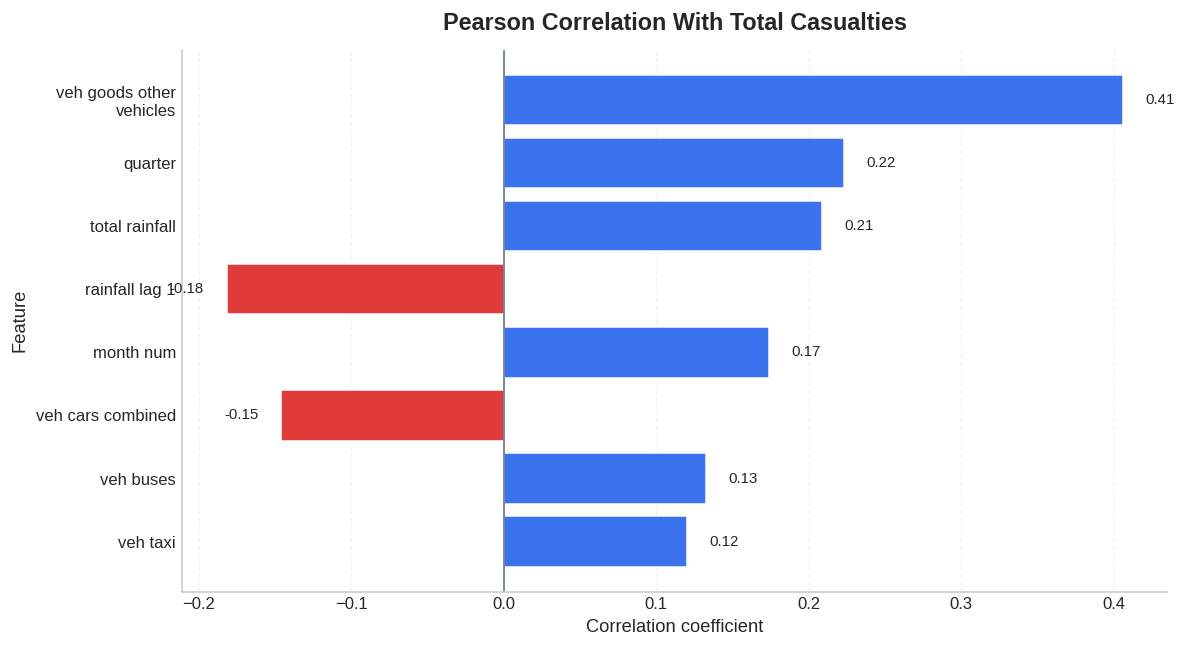

Diagnostic interpretation:
- Strongest positive associations with total casualties: veh_goods_other_vehicles, quarter, total_rainfall
- Rainfall appears to have a weaker to moderate direct association than the main vehicle exposure indicators in this integrated monthly table.
- These relationships are descriptive and diagnostic only; correlation should not be interpreted as proof of causation.


In [14]:

heading("DEPENDENCY AND ASSOCIATION ANALYSIS")

analysis_df = monthly_analytic.copy().sort_values("month").reset_index(drop=True)

# Harmonize vehicle exposure fields into analysis-ready columns
if {"veh_car", "veh_cars"}.issubset(analysis_df.columns):
    analysis_df["veh_cars_combined"] = analysis_df[["veh_cars", "veh_car"]].bfill(axis=1).iloc[:, 0]
elif "veh_cars" in analysis_df.columns:
    analysis_df["veh_cars_combined"] = analysis_df["veh_cars"]
elif "veh_car" in analysis_df.columns:
    analysis_df["veh_cars_combined"] = analysis_df["veh_car"]

if {"veh_motorcycle_and_scooter", "veh_motorcycles"}.issubset(analysis_df.columns):
    analysis_df["veh_motorcycle_exposure"] = analysis_df[["veh_motorcycles", "veh_motorcycle_and_scooter"]].bfill(axis=1).iloc[:, 0]
elif "veh_motorcycles" in analysis_df.columns:
    analysis_df["veh_motorcycle_exposure"] = analysis_df["veh_motorcycles"]
elif "veh_motorcycle_and_scooter" in analysis_df.columns:
    analysis_df["veh_motorcycle_exposure"] = analysis_df["veh_motorcycle_and_scooter"]

# Time-aware diagnostic features
analysis_df["rainfall_lag_1"] = analysis_df["total_rainfall"].shift(1)
analysis_df["casualties_lag_1"] = analysis_df["total_casualties"].shift(1)
analysis_df["casualties_lag_2"] = analysis_df["total_casualties"].shift(2)
analysis_df["rainfall_change_pct"] = analysis_df["total_rainfall"].pct_change().mul(100)
analysis_df["casualty_change_pct"] = analysis_df["total_casualties"].pct_change().mul(100)

diagnostic_features = [
    feature for feature in [
        "total_casualties",
        "total_rainfall",
        "rainfall_lag_1",
        "veh_cars_combined",
        "veh_goods_other_vehicles",
        "veh_motorcycle_exposure",
        "veh_buses",
        "veh_taxi",
        "month_num",
        "quarter",
    ]
    if feature in analysis_df.columns
]

corr_source = analysis_df[diagnostic_features].copy()
pearson_matrix = corr_source.corr(method="pearson", numeric_only=True)
correlation_with_target = (
    pearson_matrix["total_casualties"]
    .drop("total_casualties")
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .rename("pearson_corr_with_total_casualties")
    .reset_index()
    .rename(columns={"index": "feature"})
)

rainfall_association = (
    analysis_df.groupby("rainfall_level", observed=False)
    .agg(
        avg_casualties=("total_casualties", "mean"),
        avg_fatality_rate=("fatality_rate_pct", "mean"),
        avg_fatalities=("fatalities", "mean"),
        months=("month", "count"),
    )
    .round(2)
    .reset_index()
)

if "veh_motorcycle_exposure" in analysis_df.columns:
    exposure_threshold = analysis_df["veh_motorcycle_exposure"].median()
    analysis_df["motorcycle_exposure_band"] = np.where(
        analysis_df["veh_motorcycle_exposure"] >= exposure_threshold,
        "Higher motorcycle exposure",
        "Lower motorcycle exposure",
    )
    exposure_comparison = (
        analysis_df.groupby("motorcycle_exposure_band", as_index=False)
        .agg(
            avg_total_casualties=("total_casualties", "mean"),
            avg_fatality_rate=("fatality_rate_pct", "mean"),
            avg_rainfall=("total_rainfall", "mean"),
        )
        .round(2)
    )
else:
    exposure_comparison = pd.DataFrame()

safe_display(correlation_with_target, n=len(correlation_with_target))
safe_display(rainfall_association, n=len(rainfall_association))
if not exposure_comparison.empty:
    safe_display(exposure_comparison, n=len(exposure_comparison))

# Correlation heatmap using matplotlib only for portability
heatmap_df = pearson_matrix.loc[diagnostic_features, diagnostic_features]
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(heatmap_df.values, cmap="YlGnBu", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(np.arange(len(heatmap_df.columns)))
ax.set_xticklabels([clean_label(col, 14) for col in heatmap_df.columns], rotation=45, ha="right")
ax.set_yticks(np.arange(len(heatmap_df.index)))
ax.set_yticklabels([clean_label(idx, 14) for idx in heatmap_df.index])
ax.set_title("Pearson Correlation Heatmap for Key Monthly Features", pad=14, weight="bold")
for i in range(len(heatmap_df.index)):
    for j in range(len(heatmap_df.columns)):
        value = heatmap_df.iloc[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=7, color="black" if abs(value) < 0.65 else "white")
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Correlation")
plt.tight_layout()
plt.show()

top_corr_plot = correlation_with_target.head(8).copy().iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.barh(
    [clean_label(feature, 22) for feature in top_corr_plot["feature"]],
    top_corr_plot["pearson_corr_with_total_casualties"],
    color=[SECONDARY if val >= 0 else NEGATIVE for val in top_corr_plot["pearson_corr_with_total_casualties"]],
    edgecolor="white",
    alpha=0.9,
)
ax.axvline(0, color=NEUTRAL, linewidth=1)
ax.set_title("Pearson Correlation With Total Casualties", pad=12, weight="bold")
ax.set_xlabel("Correlation coefficient")
ax.set_ylabel("Feature")
ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.grid(axis="y", visible=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
for bar, value in zip(bars, top_corr_plot["pearson_corr_with_total_casualties"]):
    offset = 0.015 if value >= 0 else -0.015
    ha = "left" if value >= 0 else "right"
    ax.text(value + offset, bar.get_y() + bar.get_height()/2, f"{value:.2f}", va="center", ha=ha, fontsize=9)
plt.tight_layout()
plt.show()

top_features = correlation_with_target.head(3)["feature"].tolist()
print("Diagnostic interpretation:")
print("- Strongest positive associations with total casualties:", ", ".join(top_features) if top_features else "none identified")
print("- Rainfall appears to have a weaker to moderate direct association than the main vehicle exposure indicators in this integrated monthly table.")
print("- These relationships are descriptive and diagnostic only; correlation should not be interpreted as proof of causation.")


## 18. Predictive Analytics (Regression-First, Classification Exploratory)

This section treats **regression** as the primary predictive task because **total casualties is a continuous target**. A naive previous-month baseline, a multivariable linear regression model, and a random forest regressor are compared on a chronological hold-out period.

A smaller **exploratory classification** subsection is retained only to test whether very high-risk months can be separated from normal months. Because the integrated monthly dataset is small, all predictive results are interpreted as exploratory rather than conclusive.



PREDICTIVE ANALYTICS


,model,rmse,mae,r2
0,Naive Baseline,84.5816,66.5652,-0.5920
1,Linear Regression,137.9188,120.1835,-3.2329
2,Random Forest Regressor,64.6156,50.7133,0.0709


,month,actual_total_casualties,baseline_prediction,linear_regression_prediction,random_forest_prediction,rf_residual,lr_residual
0,2016-04-01,864.0,884.0,904.276192,905.710323,-41.710323,-40.276192
1,2016-05-01,891.0,864.0,928.940098,903.920260,-12.920260,-37.940098
2,2016-06-01,842.0,891.0,913.129580,886.306111,-44.306111,-71.129580
3,2016-07-01,963.0,842.0,966.277690,899.044594,63.955406,-3.277690
4,2016-08-01,1037.0,963.0,949.815101,898.979426,138.020574,87.184899
5,2016-09-01,852.0,1037.0,939.224211,895.069085,-43.069085,-87.224211
6,2016-10-01,927.0,852.0,982.188594,897.290883,29.709117,-55.188594
7,2016-11-01,930.0,927.0,973.985891,885.313044,44.686956,-43.985891
8,2016-12-01,842.0,930.0,947.332532,883.443841,-41.443841,-105.332532
9,2017-01-01,892.0,842.0,989.492680,893.455568,-1.455568,-97.492680


,feature,importance
9,veh_cars_combined,0.277438
0,total_rainfall,0.218100
10,veh_goods_other_vehicles,0.115987
1,rainfall_lag_1,0.101832
13,veh_taxi,0.044231
4,month_sin,0.036312
8,casualties_lag_2,0.035638
7,casualties_lag_1,0.035386
5,month_cos,0.035085
11,veh_motorcycle_exposure,0.033536


Predictive setup: chronological train/test split (first 70% train, last 30% test)
Primary predictive task: continuous prediction of monthly total casualties
Best regression model by RMSE: Random Forest Regressor
Interpretation: at least one regression model improves on the naive previous-month baseline.
Limitation: the fully integrated modeling dataset is small, so predictive results should be interpreted as exploratory rather than conclusive.


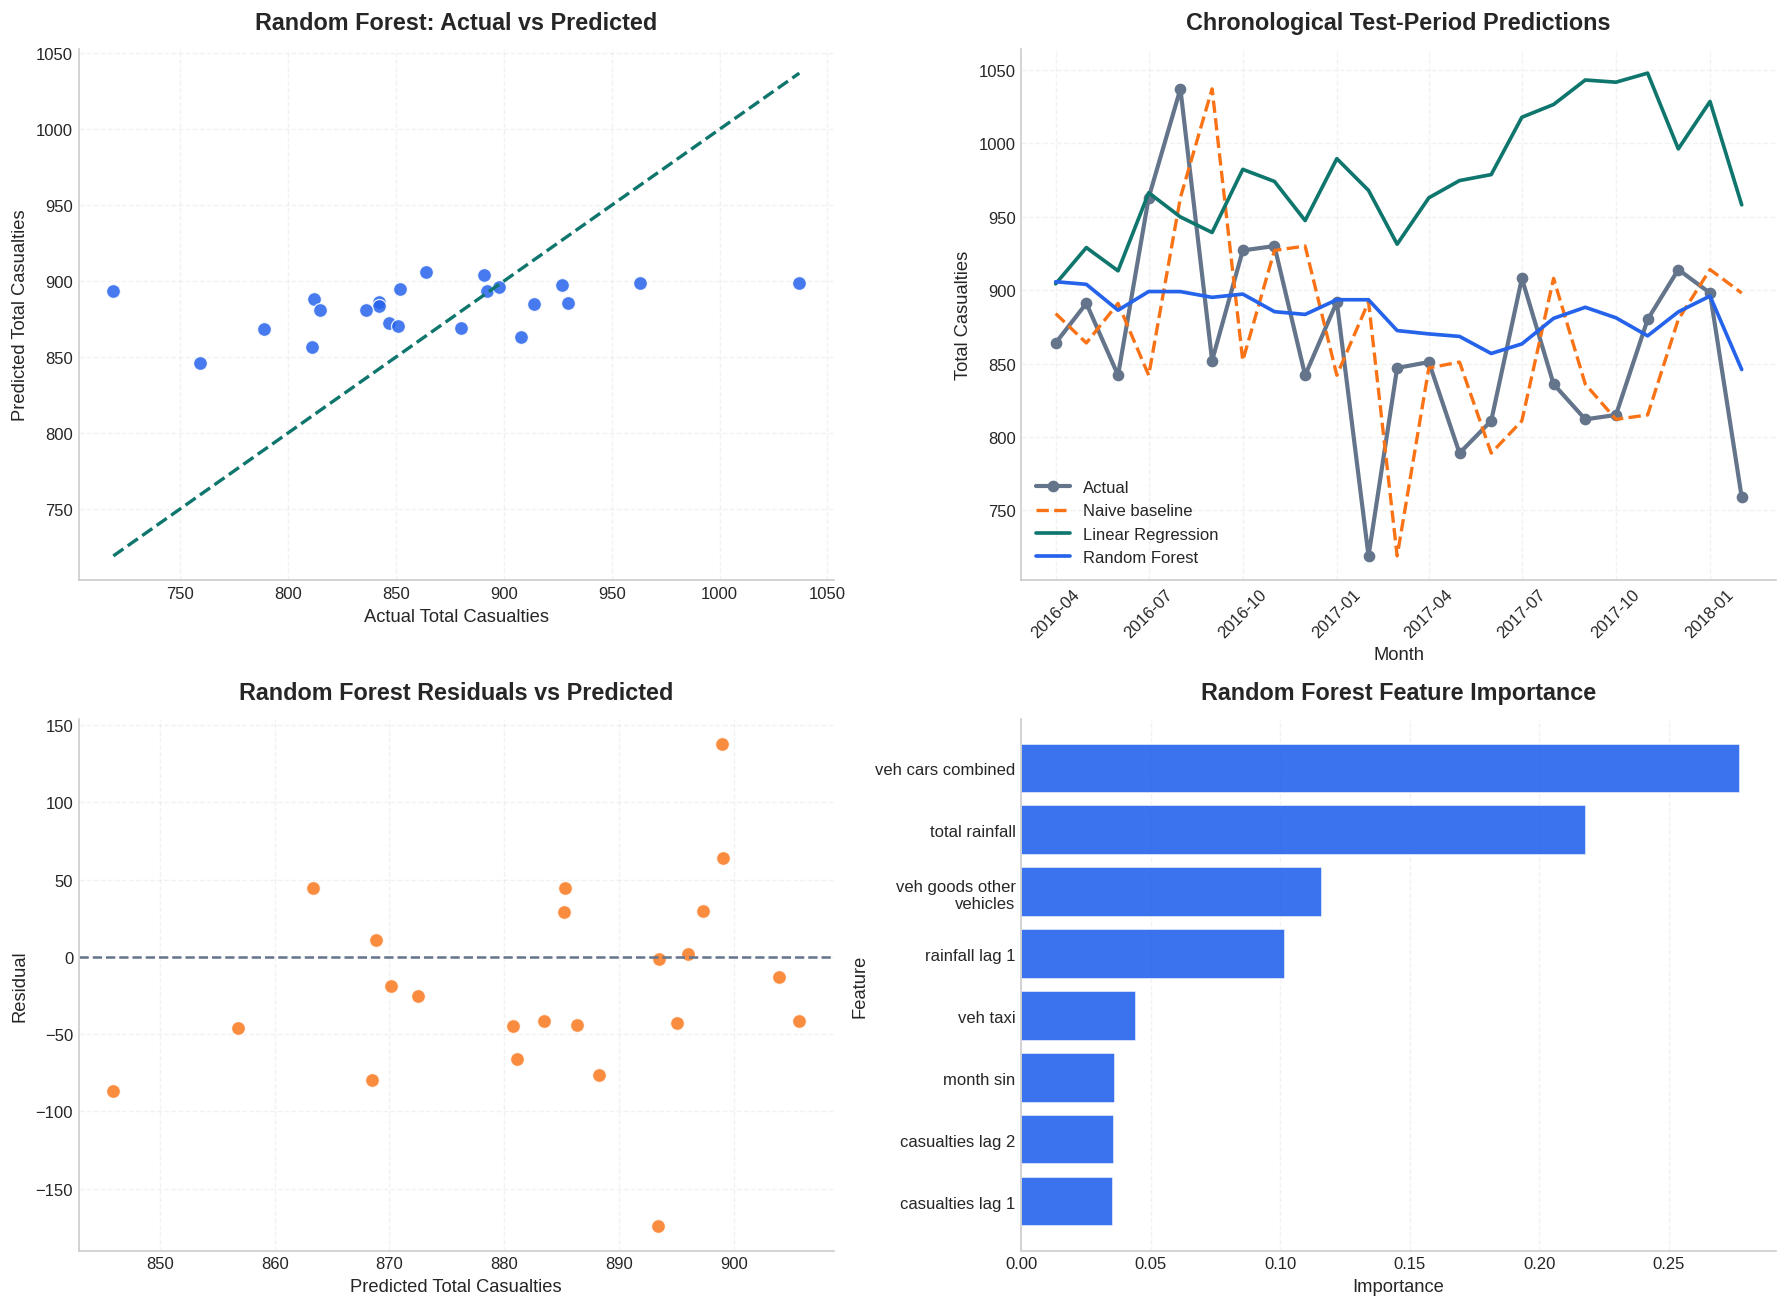


Exploratory Classification of High-Risk Months
Training high-risk threshold (top quartile of training casualties): 888.0
Train class counts:
total_casualties
0    37
1    14
Name: count, dtype: int64
Test class counts:
total_casualties
0    14
1     9
Name: count, dtype: int64
Note: total casualties are inherently continuous, so classification is secondary here and is used only to explore whether particularly high-risk months can be separated from normal months.


,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.5652,0.4737,1.0000,0.6429,0.8254
1,Random Forest Classifier,0.6522,0.5385,0.7778,0.6364,0.7460


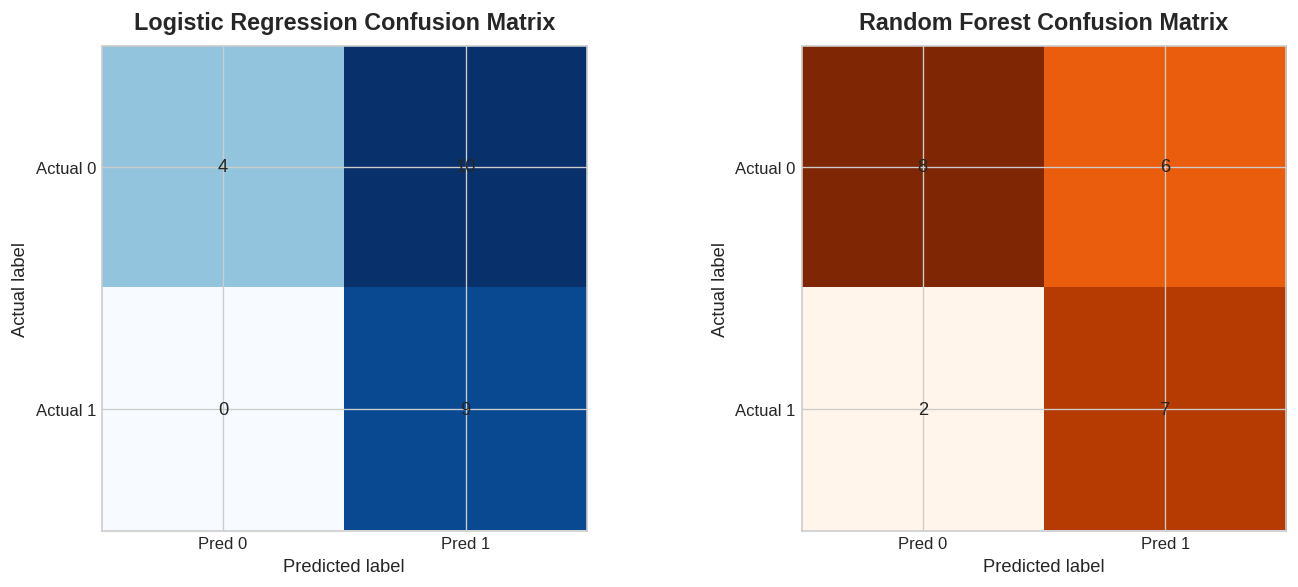

In [15]:

heading("PREDICTIVE ANALYTICS")

try:
    from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
    from sklearn.linear_model import LinearRegression, LogisticRegression
    from sklearn.metrics import (
        accuracy_score,
        confusion_matrix,
        f1_score,
        mean_absolute_error,
        mean_squared_error,
        precision_score,
        r2_score,
        recall_score,
        roc_auc_score,
    )
    from sklearn.preprocessing import StandardScaler

    target_col = "total_casualties"

    model_df = analysis_df.copy().sort_values("month").reset_index(drop=True)
    model_df["casualties_lag_1"] = model_df[target_col].shift(1)
    model_df["casualties_lag_2"] = model_df[target_col].shift(2)
    model_df["month_sin"] = np.sin(2 * np.pi * model_df["month_num"] / 12)
    model_df["month_cos"] = np.cos(2 * np.pi * model_df["month_num"] / 12)
    model_df["trend_index"] = np.arange(len(model_df))

    regression_features = [
        feature for feature in [
            "total_rainfall",
            "rainfall_lag_1",
            "month_num",
            "quarter",
            "month_sin",
            "month_cos",
            "trend_index",
            "casualties_lag_1",
            "casualties_lag_2",
            "veh_cars_combined",
            "veh_goods_other_vehicles",
            "veh_motorcycle_exposure",
            "veh_buses",
            "veh_taxi",
        ]
        if feature in model_df.columns
    ]

    model_df = model_df[["month"] + regression_features + [target_col]].copy()
    for feature in regression_features:
        model_df[feature] = model_df[feature].fillna(model_df[feature].median())
    model_df = model_df.dropna(subset=[target_col])

    if len(model_df) < 24:
        raise ValueError(f"Not enough model rows after preparation: {len(model_df)}")

    split_idx = int(len(model_df) * 0.7)
    train_df = model_df.iloc[:split_idx].copy()
    test_df = model_df.iloc[split_idx:].copy()

    X_train = train_df[regression_features]
    y_train = train_df[target_col]
    X_test = test_df[regression_features]
    y_test = test_df[target_col]

    # Naive time-series baseline: predict the previous month's casualties
    baseline_pred = test_df["casualties_lag_1"].values

    # Linear Regression on standardized features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    linreg = LinearRegression()
    linreg.fit(X_train_scaled, y_train)
    y_pred_linreg = linreg.predict(X_test_scaled)

    # Random Forest Regressor on unscaled features
    rf_reg = RandomForestRegressor(
        n_estimators=250,
        max_depth=5,
        min_samples_leaf=2,
        random_state=42,
    )
    rf_reg.fit(X_train, y_train)
    y_pred_rfreg = rf_reg.predict(X_test)

    regression_results = pd.DataFrame([
        {
            "model": "Naive Baseline",
            "rmse": mean_squared_error(y_test, baseline_pred) ** 0.5,
            "mae": mean_absolute_error(y_test, baseline_pred),
            "r2": r2_score(y_test, baseline_pred),
        },
        {
            "model": "Linear Regression",
            "rmse": mean_squared_error(y_test, y_pred_linreg) ** 0.5,
            "mae": mean_absolute_error(y_test, y_pred_linreg),
            "r2": r2_score(y_test, y_pred_linreg),
        },
        {
            "model": "Random Forest Regressor",
            "rmse": mean_squared_error(y_test, y_pred_rfreg) ** 0.5,
            "mae": mean_absolute_error(y_test, y_pred_rfreg),
            "r2": r2_score(y_test, y_pred_rfreg),
        },
    ]).round(4)

    regression_eval = pd.DataFrame({
        "month": test_df["month"].values,
        "actual_total_casualties": y_test.values,
        "baseline_prediction": baseline_pred,
        "linear_regression_prediction": y_pred_linreg,
        "random_forest_prediction": y_pred_rfreg,
    })
    regression_eval["rf_residual"] = regression_eval["actual_total_casualties"] - regression_eval["random_forest_prediction"]
    regression_eval["lr_residual"] = regression_eval["actual_total_casualties"] - regression_eval["linear_regression_prediction"]

    rf_importance = pd.DataFrame({
        "feature": regression_features,
        "importance": rf_reg.feature_importances_,
    }).sort_values("importance", ascending=False)

    safe_display(regression_results, n=len(regression_results))
    safe_display(regression_eval, n=len(regression_eval))
    safe_display(rf_importance, n=len(rf_importance))

    best_regression_model = regression_results.sort_values("rmse").iloc[0]["model"]
    baseline_rmse = regression_results.loc[regression_results["model"] == "Naive Baseline", "rmse"].iloc[0]
    best_rmse = regression_results["rmse"].min()

    print("Predictive setup: chronological train/test split (first 70% train, last 30% test)")
    print("Primary predictive task: continuous prediction of monthly total casualties")
    print("Best regression model by RMSE:", best_regression_model)
    if best_rmse < baseline_rmse:
        print("Interpretation: at least one regression model improves on the naive previous-month baseline.")
    else:
        print("Interpretation: the current regression models do not outperform the naive previous-month baseline on the held-out period.")
    print("Limitation: the fully integrated modeling dataset is small, so predictive results should be interpreted as exploratory rather than conclusive.")

    fig, axes = plt.subplots(2, 2, figsize=(15, 11))

    # 1. Actual vs predicted scatter (RF as main comparator)
    min_val = min(y_test.min(), y_pred_rfreg.min())
    max_val = max(y_test.max(), y_pred_rfreg.max())
    axes[0, 0].scatter(y_test, y_pred_rfreg, s=70, color=SECONDARY, alpha=0.85, edgecolor="white", linewidth=0.8)
    axes[0, 0].plot([min_val, max_val], [min_val, max_val], linestyle="--", color=PRIMARY, linewidth=2)
    axes[0, 0].set_title("Random Forest: Actual vs Predicted", pad=12, weight="bold")
    axes[0, 0].set_xlabel("Actual Total Casualties")
    axes[0, 0].set_ylabel("Predicted Total Casualties")
    axes[0, 0].grid(True, alpha=0.25, linestyle="--")
    axes[0, 0].spines["top"].set_visible(False)
    axes[0, 0].spines["right"].set_visible(False)

    # 2. Chronological fit
    axes[0, 1].plot(test_df["month"], y_test.values, label="Actual", color=NEUTRAL, linewidth=2.5, marker="o")
    axes[0, 1].plot(test_df["month"], baseline_pred, label="Naive baseline", color=ACCENT, linewidth=2, linestyle="--")
    axes[0, 1].plot(test_df["month"], y_pred_linreg, label="Linear Regression", color=PRIMARY, linewidth=2.2)
    axes[0, 1].plot(test_df["month"], y_pred_rfreg, label="Random Forest", color=SECONDARY, linewidth=2.2)
    axes[0, 1].set_title("Chronological Test-Period Predictions", pad=12, weight="bold")
    axes[0, 1].set_xlabel("Month")
    axes[0, 1].set_ylabel("Total Casualties")
    axes[0, 1].tick_params(axis="x", rotation=45)
    axes[0, 1].legend(frameon=False)
    axes[0, 1].grid(True, alpha=0.25, linestyle="--")
    axes[0, 1].spines["top"].set_visible(False)
    axes[0, 1].spines["right"].set_visible(False)

    # 3. Residual plot for RF
    axes[1, 0].scatter(y_pred_rfreg, y_test.values - y_pred_rfreg, color=ACCENT, s=70, alpha=0.82, edgecolor="white", linewidth=0.8)
    axes[1, 0].axhline(0, color=NEUTRAL, linestyle="--", linewidth=1.5)
    axes[1, 0].set_title("Random Forest Residuals vs Predicted", pad=12, weight="bold")
    axes[1, 0].set_xlabel("Predicted Total Casualties")
    axes[1, 0].set_ylabel("Residual")
    axes[1, 0].grid(True, alpha=0.25, linestyle="--")
    axes[1, 0].spines["top"].set_visible(False)
    axes[1, 0].spines["right"].set_visible(False)

    # 4. Feature importance
    top_importance = rf_importance.head(8).copy().iloc[::-1]
    axes[1, 1].barh(
        [clean_label(feature, 22) for feature in top_importance["feature"]],
        top_importance["importance"],
        color=SECONDARY,
        alpha=0.9,
        edgecolor="white",
    )
    axes[1, 1].set_title("Random Forest Feature Importance", pad=12, weight="bold")
    axes[1, 1].set_xlabel("Importance")
    axes[1, 1].set_ylabel("Feature")
    axes[1, 1].grid(axis="x", alpha=0.25, linestyle="--")
    axes[1, 1].grid(axis="y", visible=False)
    axes[1, 1].spines["top"].set_visible(False)
    axes[1, 1].spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

    # Exploratory classification only
    print("\nExploratory Classification of High-Risk Months")
    classification_df = model_df.copy()
    split_idx_cls = int(len(classification_df) * 0.7)
    train_cls_df = classification_df.iloc[:split_idx_cls].copy()
    test_cls_df = classification_df.iloc[split_idx_cls:].copy()

    X_train_cls = train_cls_df[regression_features]
    y_train_cont = train_cls_df[target_col]
    X_test_cls = test_cls_df[regression_features]
    y_test_cont = test_cls_df[target_col]

    threshold = y_train_cont.quantile(0.75)
    y_train_cls = (y_train_cont >= threshold).astype(int)
    y_test_cls = (y_test_cont >= threshold).astype(int)

    print("Training high-risk threshold (top quartile of training casualties):", round(float(threshold), 2))
    print("Train class counts:")
    print(y_train_cls.value_counts().sort_index())
    print("Test class counts:")
    print(y_test_cls.value_counts().sort_index())
    print("Note: total casualties are inherently continuous, so classification is secondary here and is used only to explore whether particularly high-risk months can be separated from normal months.")

    if y_test_cls.nunique() < 2 or y_train_cls.nunique() < 2:
        print("Classification evaluation skipped because the train or test period collapses to a single class, making held-out classification unstable.")
    else:
        scaler_cls = StandardScaler()
        X_train_cls_scaled = scaler_cls.fit_transform(X_train_cls)
        X_test_cls_scaled = scaler_cls.transform(X_test_cls)

        logreg = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
        logreg.fit(X_train_cls_scaled, y_train_cls)
        y_pred_log = logreg.predict(X_test_cls_scaled)
        y_prob_log = logreg.predict_proba(X_test_cls_scaled)[:, 1]

        rf_clf = RandomForestClassifier(
            n_estimators=250,
            max_depth=5,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=42,
        )
        rf_clf.fit(X_train_cls, y_train_cls)
        y_pred_rf = rf_clf.predict(X_test_cls)
        y_prob_rf = rf_clf.predict_proba(X_test_cls)[:, 1]

        classification_results = []
        for model_name, y_pred, y_prob in [
            ("Logistic Regression", y_pred_log, y_prob_log),
            ("Random Forest Classifier", y_pred_rf, y_prob_rf),
        ]:
            result = {
                "model": model_name,
                "accuracy": accuracy_score(y_test_cls, y_pred),
                "precision": precision_score(y_test_cls, y_pred, zero_division=0),
                "recall": recall_score(y_test_cls, y_pred, zero_division=0),
                "f1": f1_score(y_test_cls, y_pred, zero_division=0),
            }
            try:
                result["roc_auc"] = roc_auc_score(y_test_cls, y_prob)
            except Exception:
                result["roc_auc"] = np.nan
            classification_results.append(result)

        classification_results = pd.DataFrame(classification_results).round(4)
        safe_display(classification_results, n=len(classification_results))

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        for ax, cm, title, cmap in [
            (axes[0], confusion_matrix(y_test_cls, y_pred_log), "Logistic Regression Confusion Matrix", "Blues"),
            (axes[1], confusion_matrix(y_test_cls, y_pred_rf), "Random Forest Confusion Matrix", "Oranges"),
        ]:
            im = ax.imshow(cm, cmap=cmap)
            ax.set_title(title, pad=10, weight="bold")
            ax.set_xlabel("Predicted label")
            ax.set_ylabel("Actual label")
            ax.set_xticks([0, 1]); ax.set_xticklabels(["Pred 0", "Pred 1"])
            ax.set_yticks([0, 1]); ax.set_yticklabels(["Actual 0", "Actual 1"])
            for i in range(cm.shape[0]):
                for j in range(cm.shape[1]):
                    ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=11)
        plt.tight_layout()
        plt.show()

except Exception as exc:
    print("Predictive modeling section skipped due to:", exc)
